# Enhanced Construction Cost Estimator Notebook

## ML-Based Class 5 Construction Cost Estimator
## Final Project - Applied Analytics


In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve,GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib
import os
import warnings
import plotly.express as px
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

# Create directory for report images
os.makedirs('report_images', exist_ok=True)

# Set figure aesthetics for report-quality visualizations
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# 1. Introduction and Data Loading

In [3]:
# Introduction text
print("="*80)
print("ML-BASED CLASS 5 CONSTRUCTION COST ESTIMATOR")
print("="*80)
print("\nThis project develops a machine learning model to predict early-stage")
print("construction costs using minimal inputs, as specified by Construction Check, Inc.")
print("Target: MAPE < 25% (Mean Absolute Percentage Error)")
print("\nLoading and exploring the dataset...")

# Load data - replace with your actual file path
df = pd.read_csv('data/base_data_for_model.csv')
print(f"\nDataset loaded successfully: {df.shape[0]} projects with {df.shape[1]} features.")

# Define the allowed columns (legal to use)
best_columns = [
    # 'cpi', 
    'inflation_factor', 
    'total_project_cost_normalized_2025',
    'official_budget_range', 
    'ciqs_complexity_category', 
    'cnt_division', 'cnt_item_code', 
    # 'cnt_csi_grp_unq',
    'county_name', 
    'area_type', 
    'acf', 
    'project_latitude', 
    'project_longitude',
      'project_type', 
    'project_category',
    # 'construction_category',
    # 'project_city', 
    'project_state'
]

# Verify available columns
available_columns = [col for col in best_columns if col in df.columns]
print(f"\nUsing {len(available_columns)}  available columns (out of {len(best_columns)} possible):")
print(f"Available columns: {', '.join(available_columns)}")

# Define target variable
target = 'total_project_cost_normalized_2025'

ML-BASED CLASS 5 CONSTRUCTION COST ESTIMATOR

This project develops a machine learning model to predict early-stage
construction costs using minimal inputs, as specified by Construction Check, Inc.
Target: MAPE < 25% (Mean Absolute Percentage Error)

Loading and exploring the dataset...

Dataset loaded successfully: 17025 projects with 38 features.

Using 14  available columns (out of 14 possible):
Available columns: inflation_factor, total_project_cost_normalized_2025, official_budget_range, ciqs_complexity_category, cnt_division, cnt_item_code, county_name, area_type, acf, project_latitude, project_longitude, project_type, project_category, project_state


In [4]:
num_states = df.project_type.nunique()
print(f"Total number of Project Type: {num_states}")

Total number of Project Type: 4


2. Data Understanding and Exploration


DATA EXPLORATION

Basic statistics for numerical features:


,inflation_factor,total_project_cost_normalized_2025,cnt_division,cnt_item_code,acf,project_latitude,project_longitude
count,17025.000000,1.702500e+04,17025.000000,17025.000000,17025.000000,17025.000000,17025.000000
mean,1.165945,1.142250e+06,10.932511,13.145551,0.987339,39.817973,-86.567526
std,0.103935,1.159616e+06,6.390413,9.585192,0.068659,3.845962,8.969502
min,1.000000,1.052755e+05,1.000000,1.000000,0.800000,29.598000,-124.303060
25%,1.054916,3.499491e+05,5.000000,6.000000,0.950000,38.365830,-93.250000
50%,1.184201,6.890211e+05,10.000000,10.000000,0.990000,39.830000,-84.410000
75%,1.254595,1.493053e+06,16.000000,19.000000,1.020000,42.331427,-80.652000
max,1.336667,5.758659e+06,29.000000,61.000000,1.190000,48.916110,-70.920663


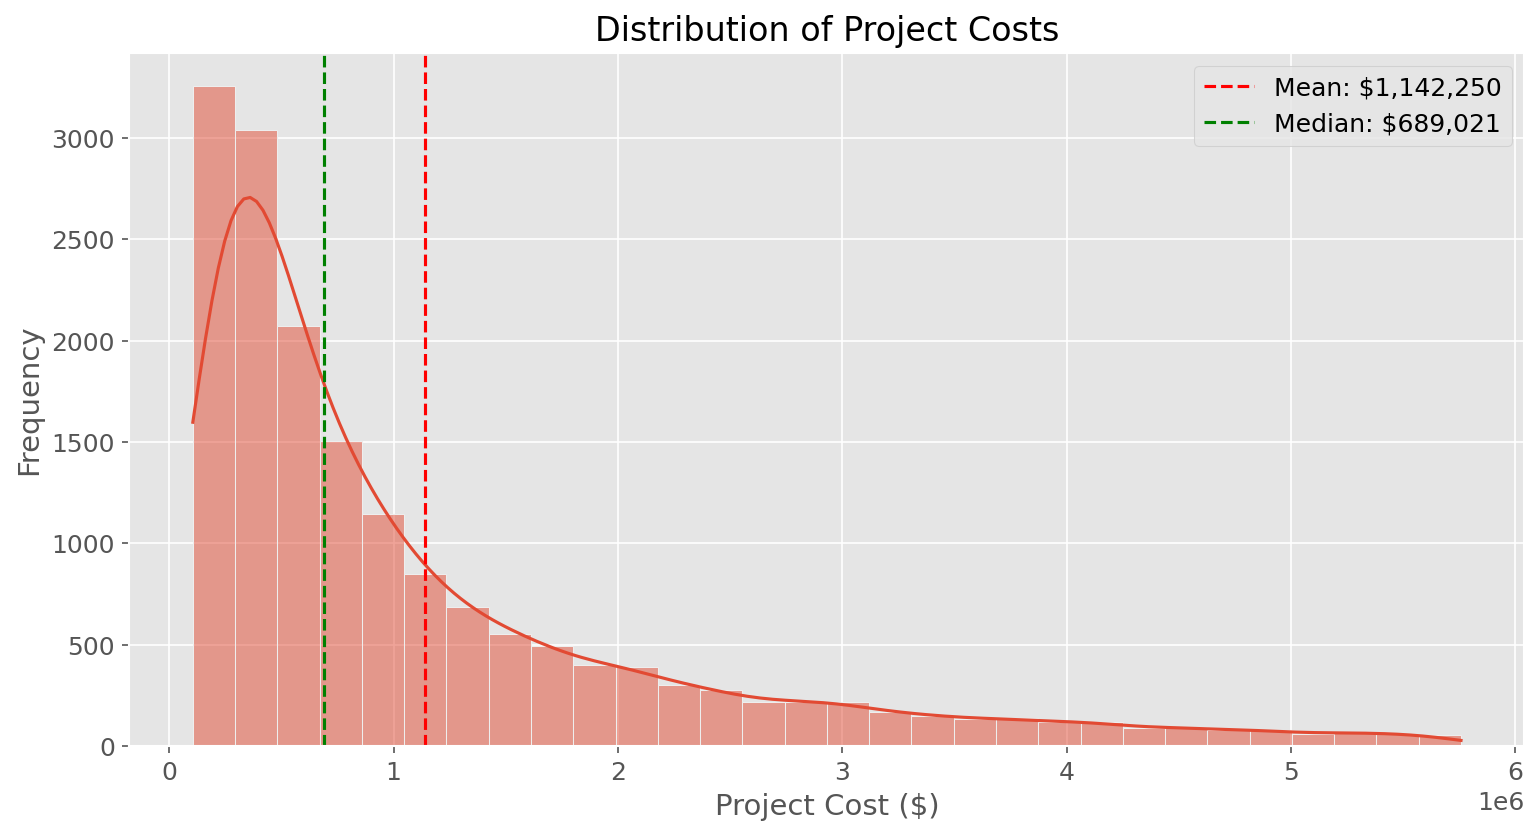


The cost distribution is right-skewed, which is expected for construction costs.
Most projects fall in the lower range, with fewer high-cost outlier projects.


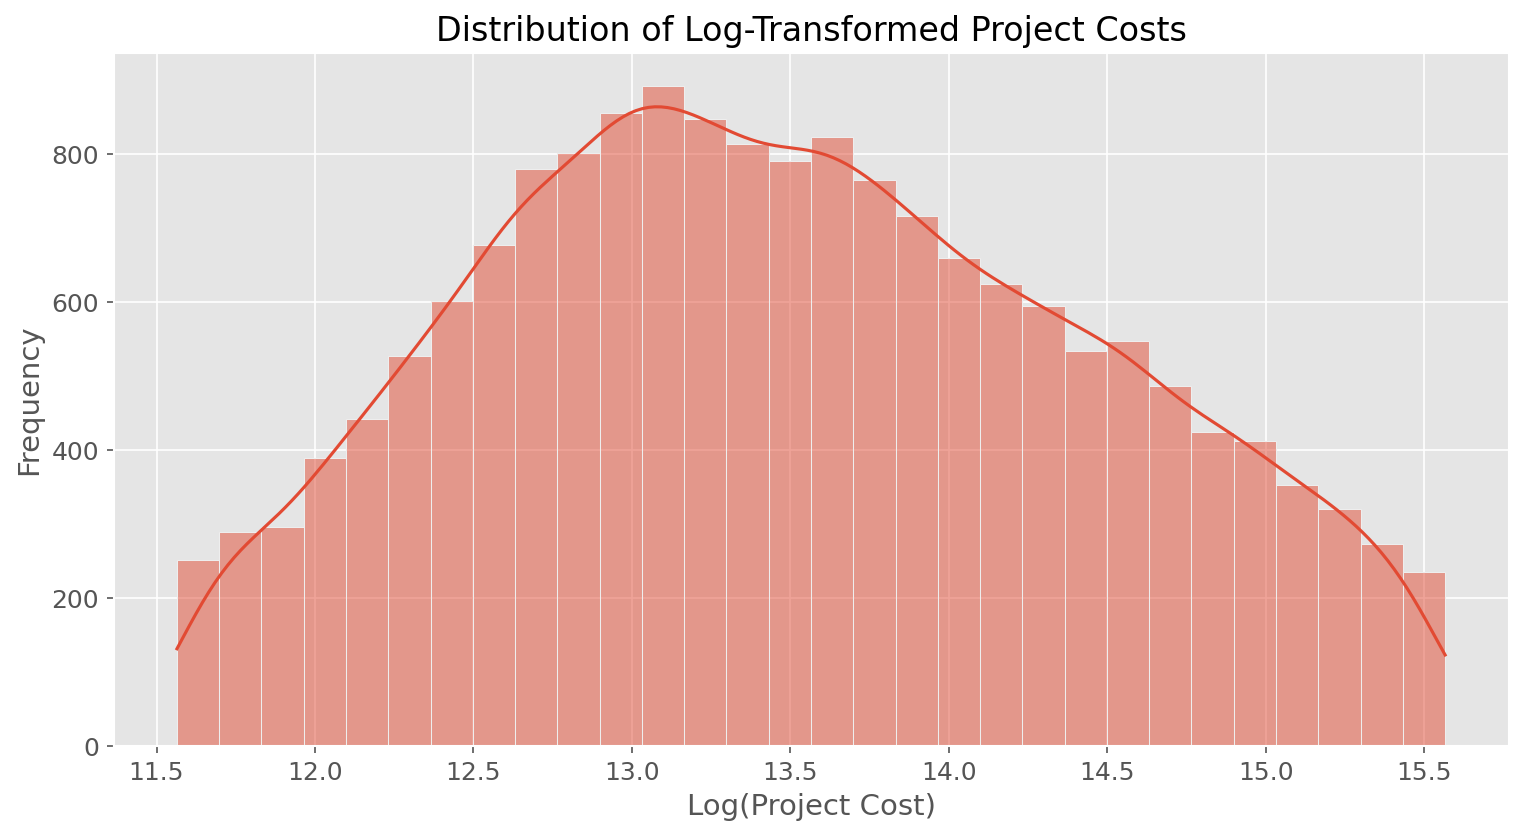


After log transformation, the distribution becomes more normal,
suggesting that working with log-transformed costs could improve model performance.

Categorical features: official_budget_range, ciqs_complexity_category, county_name, area_type, project_type, project_category, project_state


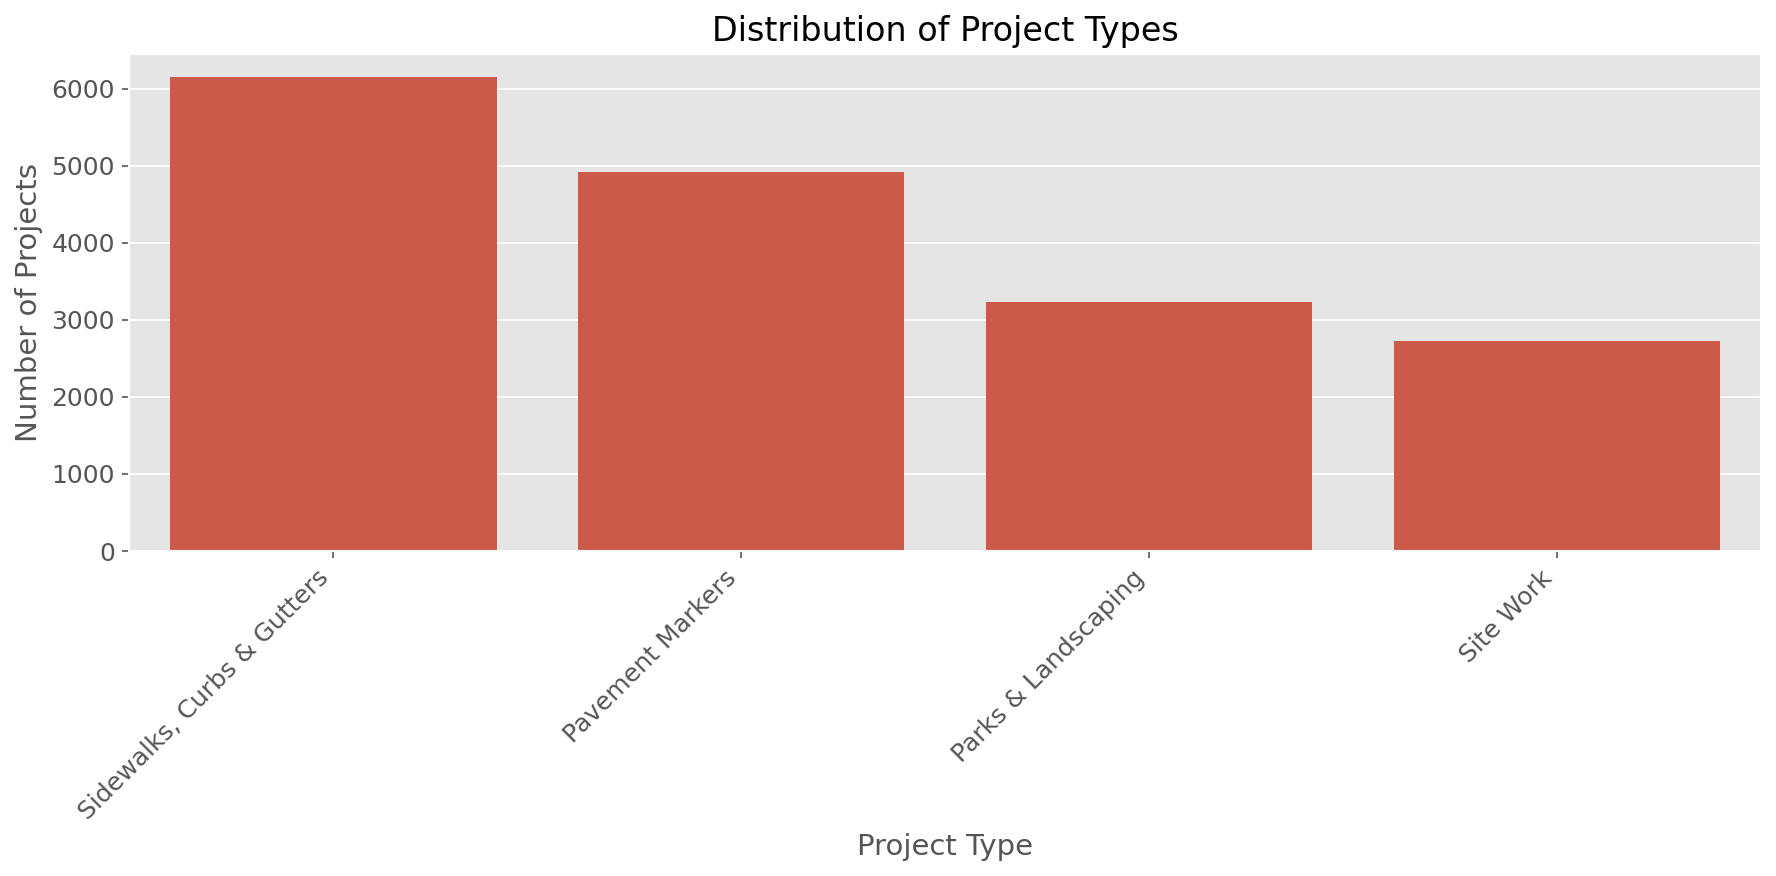


The project types distribution shows which types of construction projects
are most common in our dataset, with significant variations in frequency.


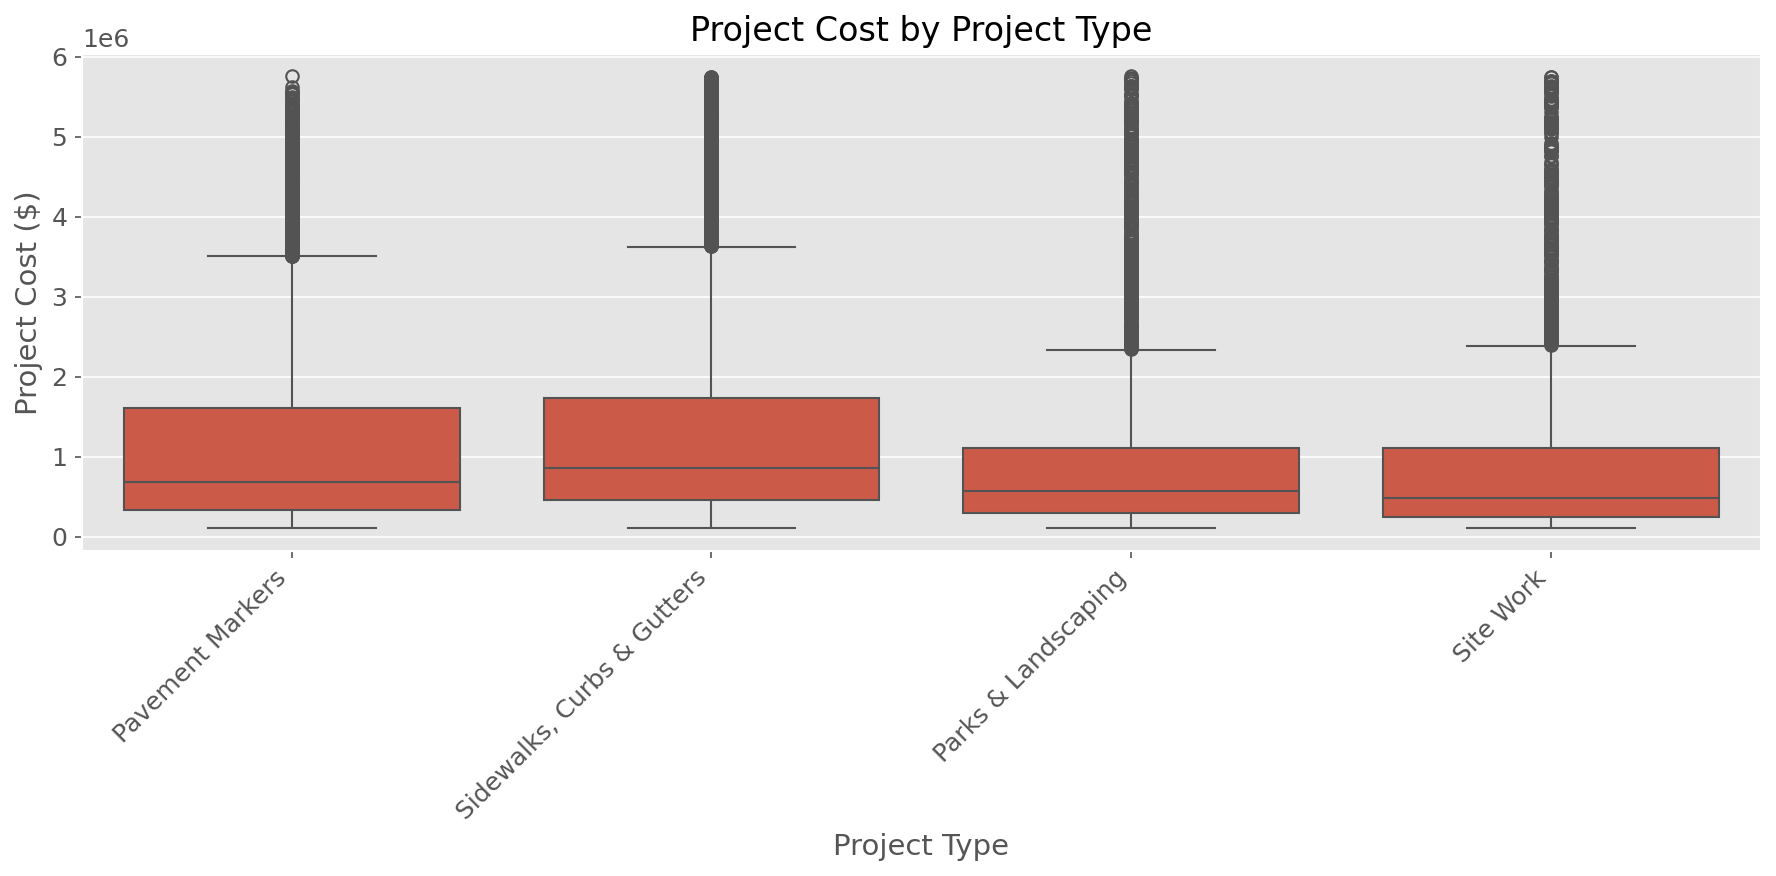


The box plots reveal significant cost variations between different project types.
This confirms project_type will be an important predictor in our model.



The geographic visualization shows how projects are distributed across locations
with colors indicating cost levels. This highlights regional cost variations.

Numerical features: inflation_factor, cnt_division, cnt_item_code, acf


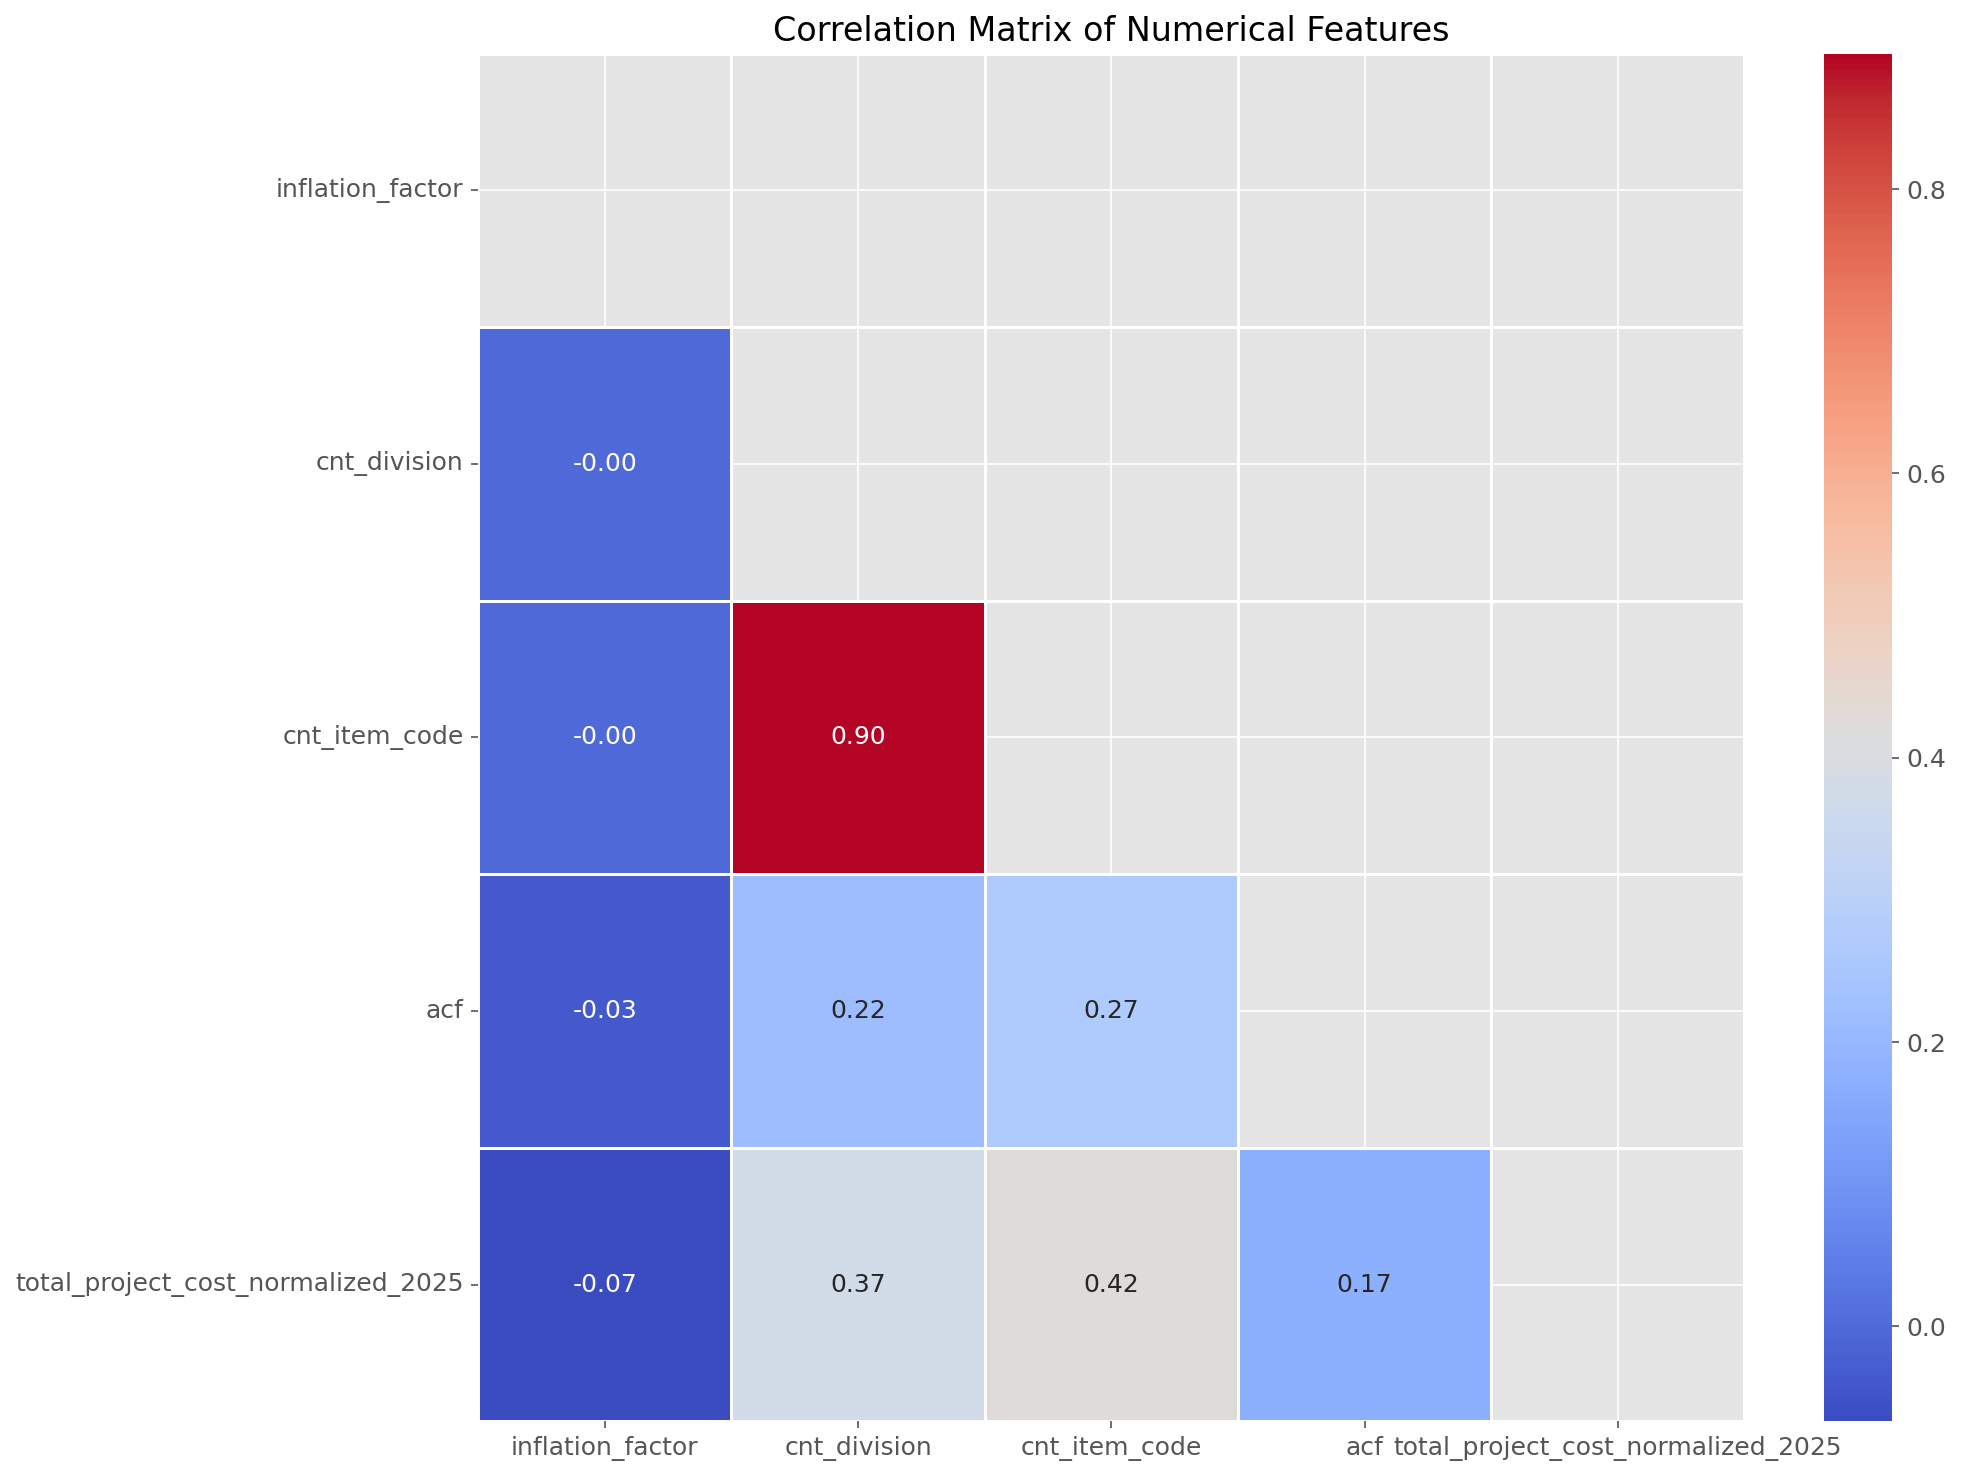


The correlation matrix reveals relationships between numerical features and the target.
Features with higher correlation coefficients have stronger relationships with project cost.


In [5]:
# Basic statistics
print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

print("\nBasic statistics for numerical features:")
display(df[available_columns].describe())

# Target variable distribution
plt.figure(figsize=(12, 6))
sns.histplot(df[target], kde=True, bins=30)
plt.title('Distribution of Project Costs')
plt.xlabel('Project Cost ($)')
plt.ylabel('Frequency')
plt.axvline(df[target].mean(), color='red', linestyle='--', label=f'Mean: ${df[target].mean():,.0f}')
plt.axvline(df[target].median(), color='green', linestyle='--', label=f'Median: ${df[target].median():,.0f}')
plt.legend()
plt.savefig('report_images/cost_distribution.png')
plt.show()

print("\nThe cost distribution is right-skewed, which is expected for construction costs.")
print("Most projects fall in the lower range, with fewer high-cost outlier projects.")

# Check for log transformation
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(df[target]), kde=True, bins=30)
plt.title('Distribution of Log-Transformed Project Costs')
plt.xlabel('Log(Project Cost)')
plt.ylabel('Frequency')
plt.savefig('report_images/log_cost_distribution.png')
plt.show()

print("\nAfter log transformation, the distribution becomes more normal,")
print("suggesting that working with log-transformed costs could improve model performance.")

# Categorical feature analysis
categorical_features = [col for col in available_columns if col not in [target] and df[col].dtype == 'object']
print(f"\nCategorical features: {', '.join(categorical_features)}")

# Show project types distribution
plt.figure(figsize=(12, 6))
project_counts = df['project_type'].value_counts()
sns.barplot(x=project_counts.index, y=project_counts.values)
plt.title('Distribution of Project Types')
plt.ylabel('Number of Projects')
plt.xlabel('Project Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('report_images/project_types.png')
plt.show()

print("\nThe project types distribution shows which types of construction projects")
print("are most common in our dataset, with significant variations in frequency.")

# Cost by project type
plt.figure(figsize=(12, 6))
sns.boxplot(x='project_type', y=target, data=df)
plt.title('Project Cost by Project Type')
plt.ylabel('Project Cost ($)')
plt.xlabel('Project Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('report_images/cost_by_project_type.png')
plt.show()

print("\nThe box plots reveal significant cost variations between different project types.")
print("This confirms project_type will be an important predictor in our model.")

# Geographical distribution of projects

# Color mapping
color_map = {
    "Pavement Markers": "darkblue",
    "Parks & Landscaping": "black",
    "Sidewalks, Curbs & Gutters": "green",
    "Site Work": "orange"
}

fig = px.scatter_mapbox(
    df,
    lat="project_latitude",
    lon="project_longitude",
    color="project_type",
    size="total_project_cost_normalized_2025",
    hover_name="project_type",
    hover_data=["total_project_cost_normalized_2025"],
    zoom=3,
    mapbox_style="open-street-map",
    color_discrete_map=color_map,
    title="Geographical Distribution of Project Cost by Project Type"
)

fig.show()

print("\nThe geographic visualization shows how projects are distributed across locations")
print("with colors indicating cost levels. This highlights regional cost variations.")

# Numerical feature correlations
numerical_features = [col for col in available_columns 
                      if col not in [target,'project_latitude','project_longitude'] and df[col].dtype in ['int64', 'float64']]
print(f"\nNumerical features: {', '.join(numerical_features)}")

plt.figure(figsize=(14, 10))
correlation = df[numerical_features + [target]].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('report_images/correlation_matrix.png')
plt.show()

print("\nThe correlation matrix reveals relationships between numerical features and the target.")
print("Features with higher correlation coefficients have stronger relationships with project cost.")

# 3. Data Preprocessing and Feature Engineering


DATA PREPROCESSING AND FEATURE ENGINEERING

Handling missing values and creating a clean dataset...
Handled 0 missing values. Remaining missing: 0

Feature Engineering:
1. Creating regional clusters from states and geographic coordinates
2. Generating complexity score from division and item counts
3. Creating economic factor from CPI and inflation


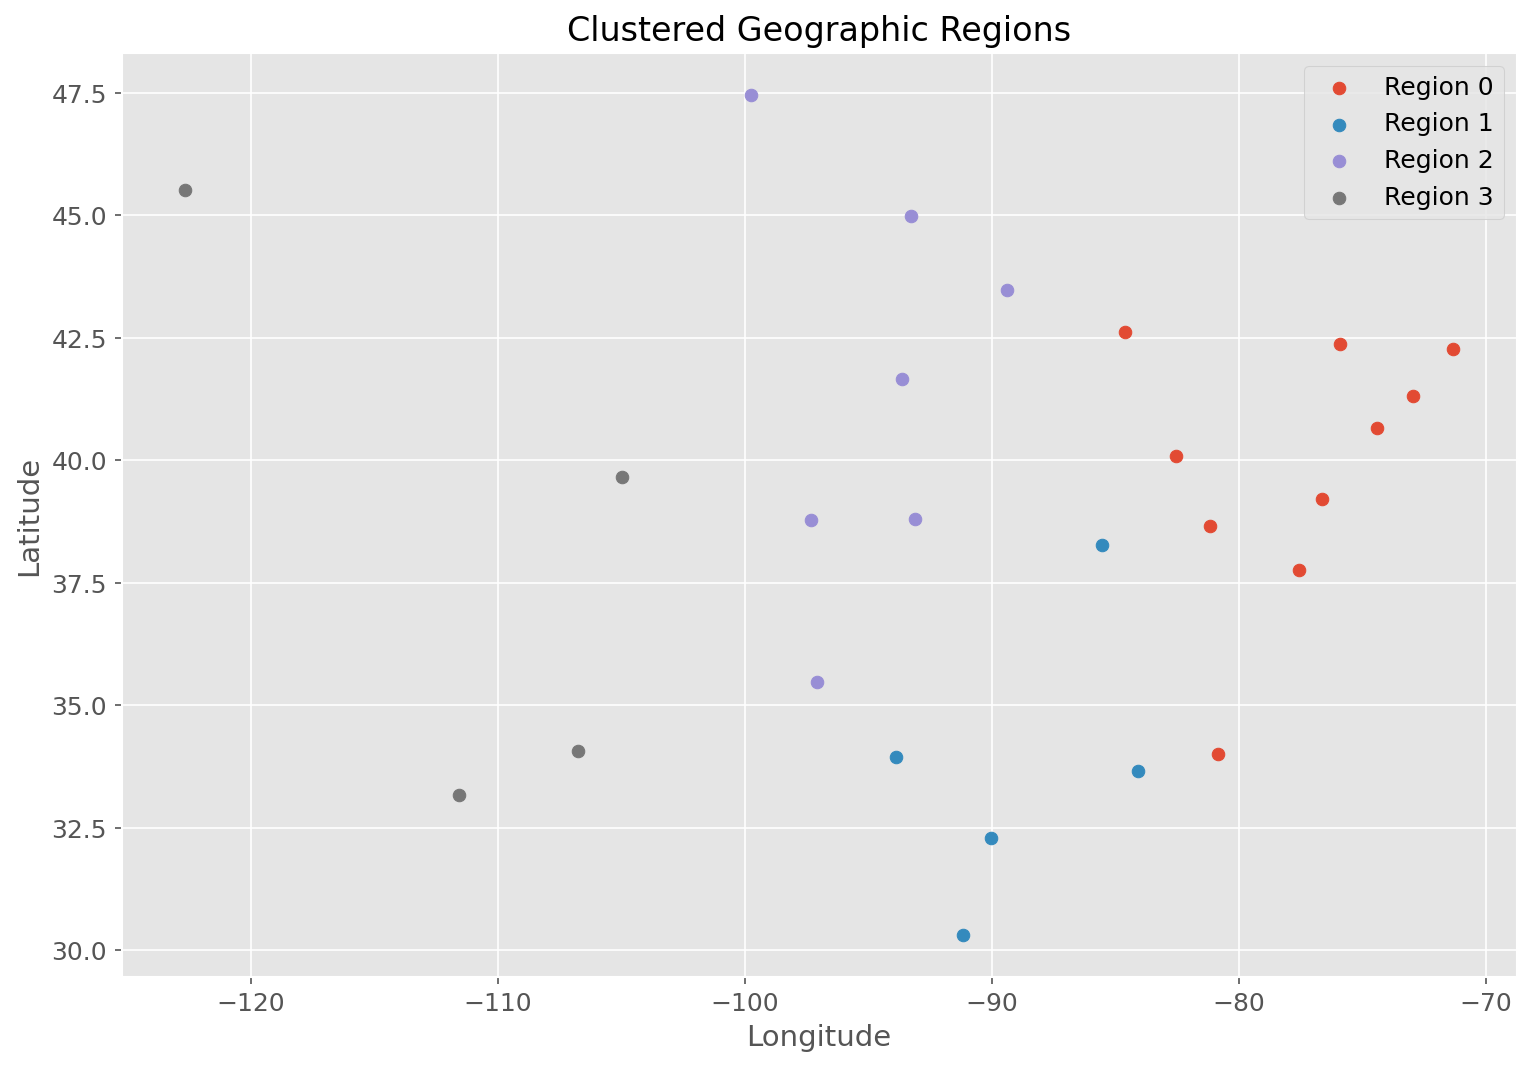


Created 4 geographic regions based on clustering state coordinates.

Engineered features: region


,region
count,17025
unique,4
top,Region_0
freq,9767


In [6]:
print("\n" + "="*80)
print("DATA PREPROCESSING AND FEATURE ENGINEERING")
print("="*80)

print("\nHandling missing values and creating a clean dataset...")

# Create a copy with only available columns
df_clean = df[available_columns].copy()

# Handle missing values
missing_before = df_clean.isnull().sum().sum()
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['int64', 'float64']:
            # Fill numerical with median
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            # Fill categorical with mode
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
missing_after = df_clean.isnull().sum().sum()

print(f"Handled {missing_before} missing values. Remaining missing: {missing_after}")

print("\nFeature Engineering:")
print("1. Creating regional clusters from states and geographic coordinates")
print("2. Generating complexity score from division and item counts")
print("3. Creating economic factor from CPI and inflation")

# 1. Create region from states using clustering
from sklearn.cluster import KMeans

# Create state-level coordinates
state_coords = {}
for state in df_clean['project_state'].unique():
    if 'project_latitude' in df_clean.columns and 'project_longitude' in df_clean.columns:
        state_data = df_clean[df_clean['project_state'] == state]
        lat = state_data['project_latitude'].median()
        lng = state_data['project_longitude'].median()
        if not np.isnan(lat) and not np.isnan(lng):
            state_coords[state] = (lat, lng)

# Only proceed with clustering if we have coordinates
if state_coords:
    # Create array for clustering
    states = list(state_coords.keys())
    coords = np.array([state_coords[state] for state in states])
    
    # Choose optimal number of regions (4 is reasonable)
    optimal_k = min(4, len(coords))
    
    # Apply k-means 
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    kmeans.fit(coords)
    
    # Create state to region mapping
    state_to_region = {}
    for i, state in enumerate(states):
        region = kmeans.predict(np.array([state_coords[state]]).reshape(1, -1))[0]
        state_to_region[state] = f"Region_{region}"
    
    # Add region to dataset
    df_clean['region'] = df_clean['project_state'].map(state_to_region)
    
    # Visualize regions
    plt.figure(figsize=(12, 8))
    for region in range(optimal_k):
        region_states = [state for state, reg in state_to_region.items() if reg == f"Region_{region}"]
        region_coords = np.array([state_coords[state] for state in region_states])
        plt.scatter(region_coords[:, 1], region_coords[:, 0], label=f"Region {region}")
    
    plt.title("Clustered Geographic Regions")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.savefig('report_images/clustered_regions.png')
    plt.show()
    
    print(f"\nCreated {optimal_k} geographic regions based on clustering state coordinates.")

# 2. Create complexity score
if all(col in df_clean.columns for col in ['cnt_division', 'cnt_item_code', 'cnt_csi_grp_unq']):
    df_clean['complexity_score'] = (df_clean['cnt_division'] * df_clean['cnt_item_code'] / 
                                   df_clean['cnt_csi_grp_unq'].clip(lower=1))
    
    # Visualize relationship with cost
    plt.figure(figsize=(10, 6))
    plt.scatter(df_clean['complexity_score'], df_clean[target], alpha=0.5)
    plt.title('Project Complexity vs. Cost')
    plt.xlabel('Complexity Score')
    plt.ylabel('Project Cost ($)')
    plt.savefig('report_images/complexity_vs_cost.png')
    plt.show()
    
    print("\nCreated complexity score that captures project intricacy based on divisions and components.")
    print("The scatter plot shows how project complexity relates to overall cost.")

# 3. Create economic factor
if all(col in df_clean.columns for col in ['cpi', 'inflation_factor']):
    df_clean['economic_factor'] = df_clean['cpi'] * df_clean['inflation_factor']
    
    print("\nCreated economic factor combining CPI and inflation metrics.")

# Print new engineered features
new_features = [col for col in df_clean.columns if col not in available_columns]
print(f"\nEngineered features: {', '.join(new_features)}")

# Display summary of new features
if new_features:
    display(df_clean[new_features].describe())

# 4. Model Development and Training


MODEL DEVELOPMENT
['inflation_factor', 'official_budget_range', 'ciqs_complexity_category', 'cnt_division', 'cnt_item_code', 'county_name', 'area_type', 'acf', 'project_type', 'project_category', 'project_state', 'region']
Training set: 13620 samples
Test set: 3405 samples

Categorical features for encoding: 8
Numerical features for scaling: 4

Training and evaluating multiple model types:
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

Training Random Forest...
Random Forest - CV MAPE: 23.50%, Train MAPE: 14.49%, Test MAPE: 22.18%, R²: 0.9435


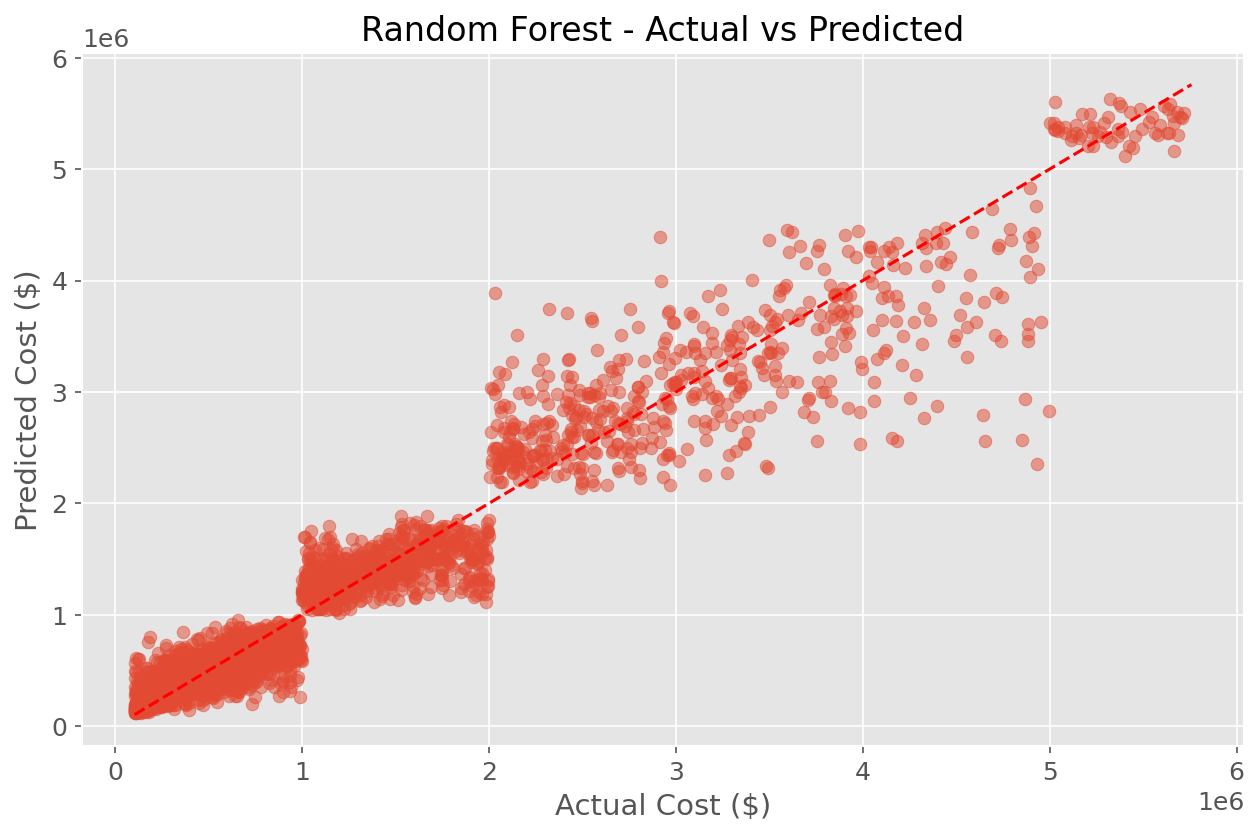

Features used: ['inflation_factor', 'official_budget_range', 'ciqs_complexity_category', 'cnt_division', 'cnt_item_code', 'county_name', 'area_type', 'acf', 'project_type', 'project_category', 'project_state', 'region']
Categorical columns for encoding: ['official_budget_range', 'ciqs_complexity_category', 'county_name', 'area_type', 'project_type', 'project_category', 'project_state', 'region']

Training Gradient Boosting...
Gradient Boosting - CV MAPE: 42.95%, Train MAPE: 42.53%, Test MAPE: 44.28%, R²: 0.9013


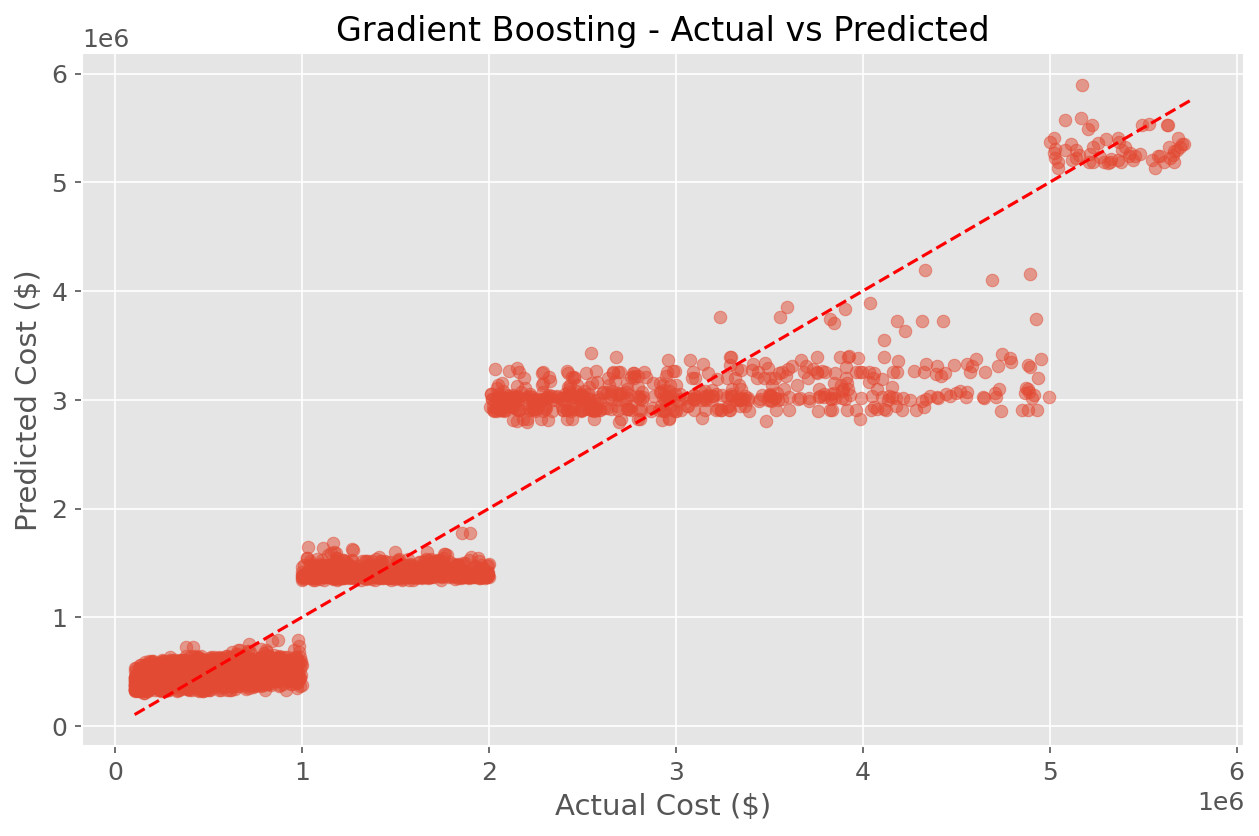

Features used: ['inflation_factor', 'official_budget_range', 'ciqs_complexity_category', 'cnt_division', 'cnt_item_code', 'county_name', 'area_type', 'acf', 'project_type', 'project_category', 'project_state', 'region']
Categorical columns for encoding: ['official_budget_range', 'ciqs_complexity_category', 'county_name', 'area_type', 'project_type', 'project_category', 'project_state', 'region']

Training XGBoost...
XGBoost - CV MAPE: 37.48%, Train MAPE: 34.88%, Test MAPE: 37.85%, R²: 0.9226


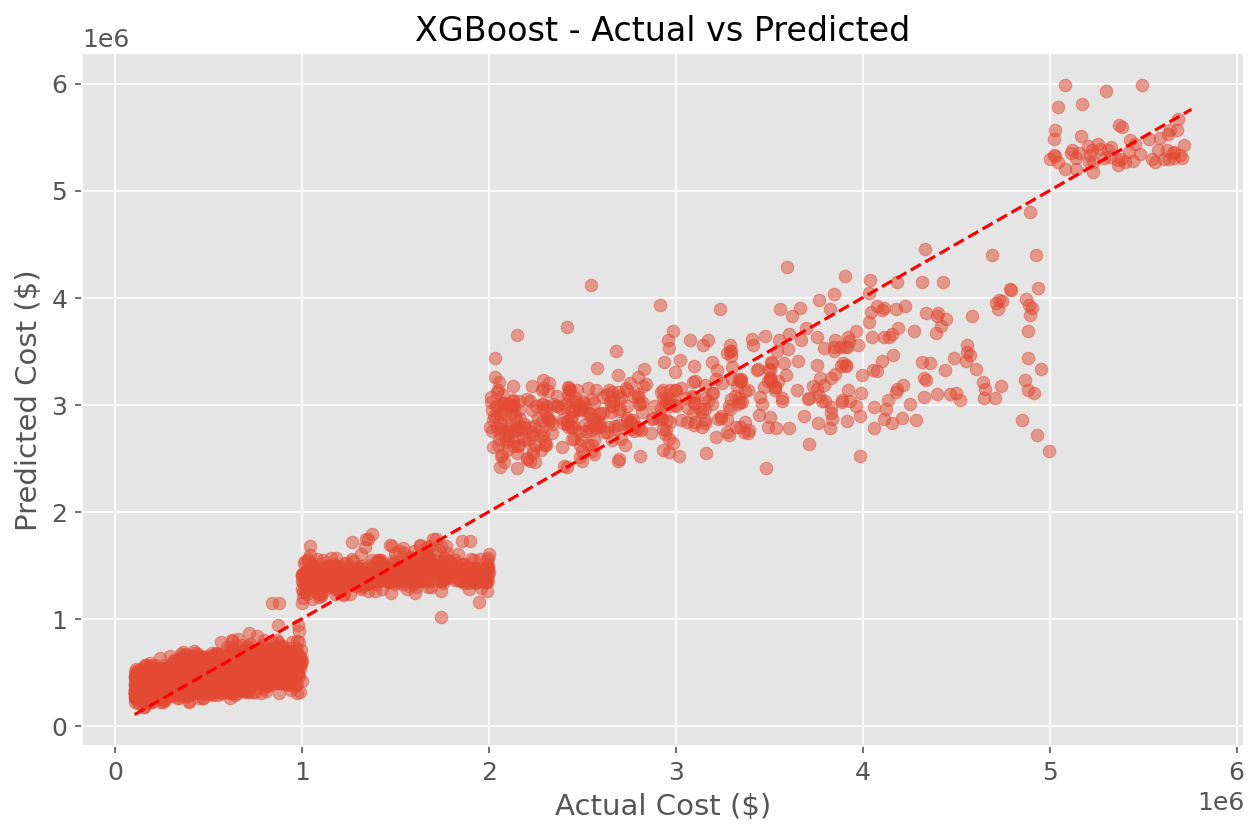

Features used: ['inflation_factor', 'official_budget_range', 'ciqs_complexity_category', 'cnt_division', 'cnt_item_code', 'county_name', 'area_type', 'acf', 'project_type', 'project_category', 'project_state', 'region']
Categorical columns for encoding: ['official_budget_range', 'ciqs_complexity_category', 'county_name', 'area_type', 'project_type', 'project_category', 'project_state', 'region']

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 490
[LightGBM] [Info] Number of data points in the train set: 10896, number of used features: 193
[LightGBM] [Info] Start training from score 1145285.575561
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And i

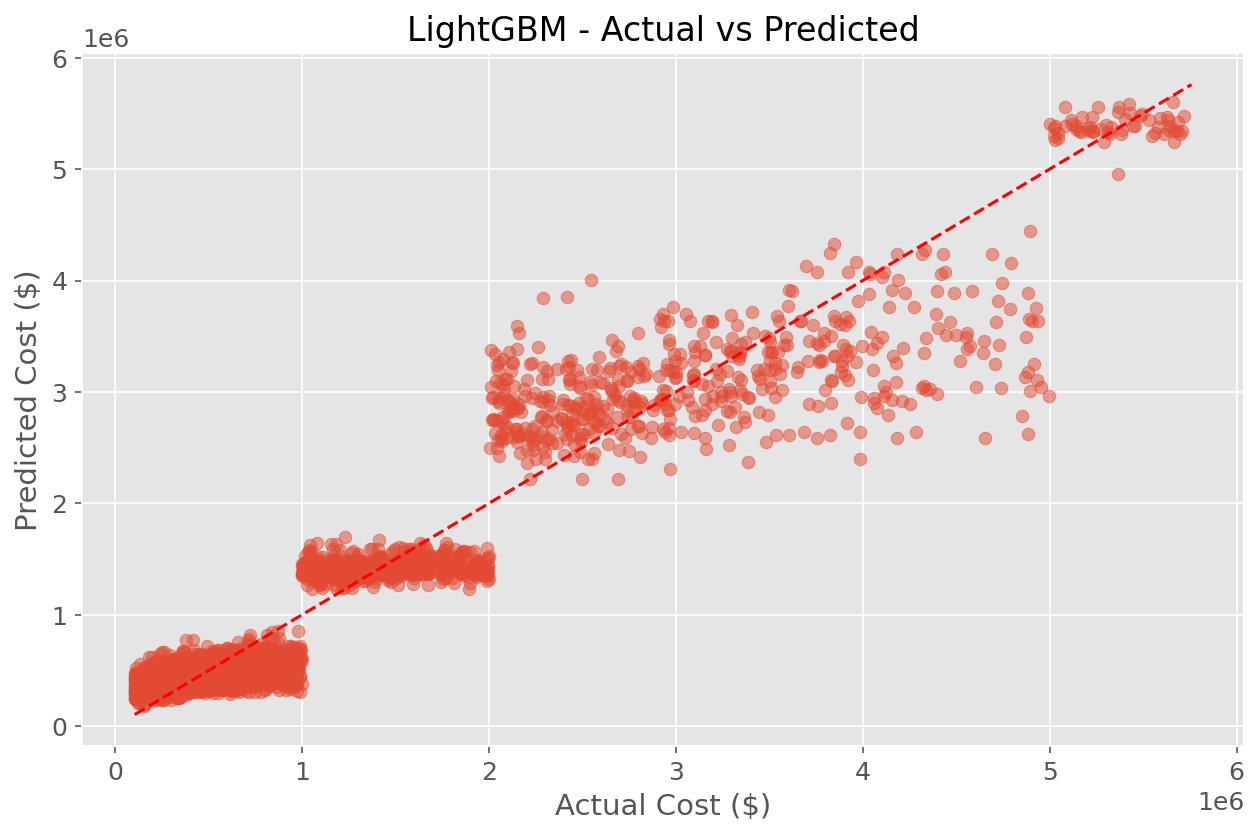

Features used: ['inflation_factor', 'official_budget_range', 'ciqs_complexity_category', 'cnt_division', 'cnt_item_code', 'county_name', 'area_type', 'acf', 'project_type', 'project_category', 'project_state', 'region']
Categorical columns for encoding: ['official_budget_range', 'ciqs_complexity_category', 'county_name', 'area_type', 'project_type', 'project_category', 'project_state', 'region']


In [7]:
print("\n" + "="*80)
print("MODEL DEVELOPMENT")
print("="*80)

# Prepare features and target
# features = [col for col in df_clean.columns if col != target]
features = [col for col in df_clean.columns if col not in [target, "project_latitude","project_longitude"]]
X = df_clean[features]
y = df_clean[target]
print(features)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Identify categorical and numerical features
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
numerical_cols = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]

print(f"\nCategorical features for encoding: {len(categorical_cols)}")
print(f"Numerical features for scaling: {len(numerical_cols)}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Define models to evaluate
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42)
}

# # Define parameter grid for Random Forest
# param_grid_rf = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5, 10]
# }

# # Run Grid Search
# rf = RandomForestRegressor(random_state=42)
# rf_grid = GridSearchCV(rf, param_grid_rf, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
# rf_grid.fit(X, y)  # X and y are your features and target variables

# # Use the best estimator from GridSearchCV
# models = {
#     'Random Forest': rf_grid.best_estimator_,
#     'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
#     'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
#     'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42)
# }

print("\nTraining and evaluating multiple model types:")
for name in models.keys():
    print(f"- {name}")

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        pipeline, X_train, y_train, 
        cv=cv, 
        scoring='neg_mean_absolute_percentage_error'
    )
    cv_mape = -np.mean(cv_scores) * 100
    
    # Train on full training set
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Metrics
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred) * 100
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    results[name] = {
        'cv_mape': cv_mape,
        'train_mape': train_mape,
        'test_mape': test_mape,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'pipeline': pipeline
    }
    
    print(f"{name} - CV MAPE: {cv_mape:.2f}%, Train MAPE: {train_mape:.2f}%, Test MAPE: {test_mape:.2f}%, R²: {test_r2:.4f}")
    
    # Plot actual vs predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.title(f'{name} - Actual vs Predicted')
    plt.xlabel('Actual Cost ($)')
    plt.ylabel('Predicted Cost ($)')
    plt.savefig(f'report_images/{name.replace(" ", "_").lower()}_actual_vs_predicted.png')
    plt.show()
    print("Features used:", features)
    print("Categorical columns for encoding:", categorical_cols)

In [8]:
print("Features used by the model:")
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
for feature in list(feature_names):
    print("-", feature)


Features used by the model:
- num__inflation_factor
- num__cnt_division
- num__cnt_item_code
- num__acf
- cat__official_budget_range_$1M-$2M
- cat__official_budget_range_$2M-$5M
- cat__official_budget_range_$5M-$10M
- cat__official_budget_range_Less than $1M
- cat__ciqs_complexity_category_Category 1
- cat__ciqs_complexity_category_Category 2
- cat__ciqs_complexity_category_Category 3
- cat__ciqs_complexity_category_Category 4
- cat__ciqs_complexity_category_Category 5
- cat__ciqs_complexity_category_Category 6
- cat__ciqs_complexity_category_Category 7
- cat__county_name_Abbeville County
- cat__county_name_Acadia Parish
- cat__county_name_Accomack County
- cat__county_name_Adair County
- cat__county_name_Adams County
- cat__county_name_Aiken County
- cat__county_name_Aitkin County
- cat__county_name_Albany County
- cat__county_name_Alcona County
- cat__county_name_Alexandria city
- cat__county_name_Alger County
- cat__county_name_Allamakee County
- cat__county_name_Allegan County
- ca

# 5. Model Evaluation and Selection


MODEL EVALUATION

Model Comparison:


,CV MAPE (%),Train MAPE (%),Test MAPE (%),Test RMSE ($),Test R²
Random Forest,23.496106,14.491106,22.179494,278644.982497,0.943470
Gradient Boosting,42.952714,42.529862,44.277194,368130.441581,0.901332
XGBoost,37.483358,34.881486,37.845974,325968.785164,0.922638
LightGBM,38.202587,36.504135,38.981447,338575.682050,0.916539


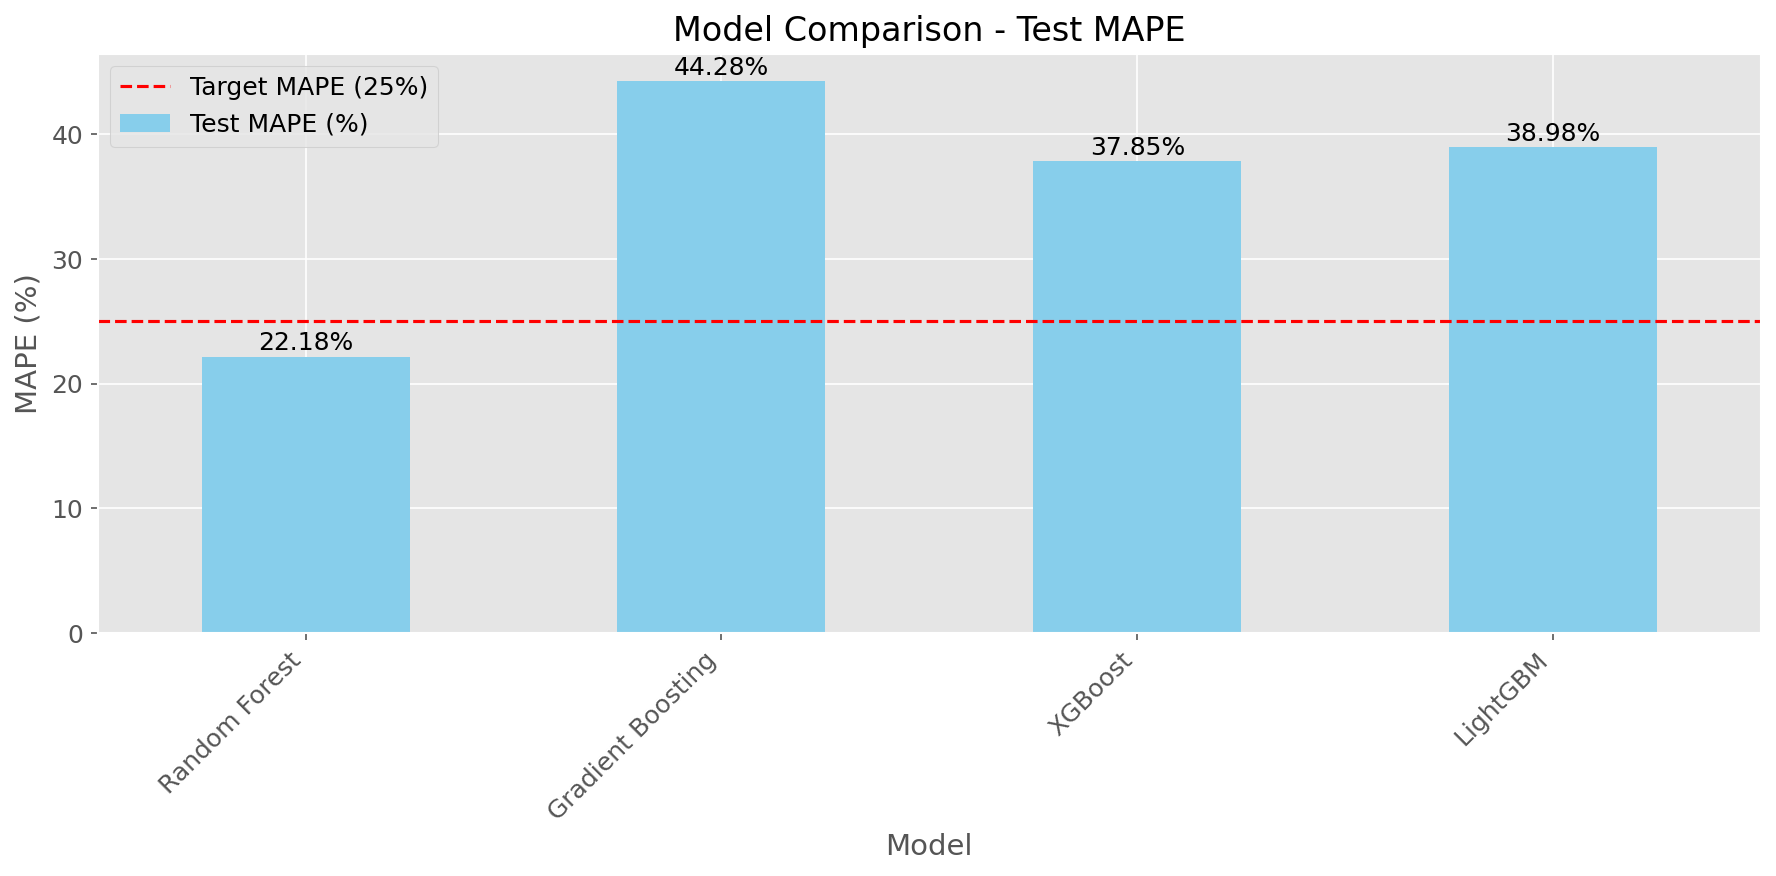


The bar chart compares the MAPE across different model types.
Models with MAPE below the red dashed line (25%) meet our performance target.


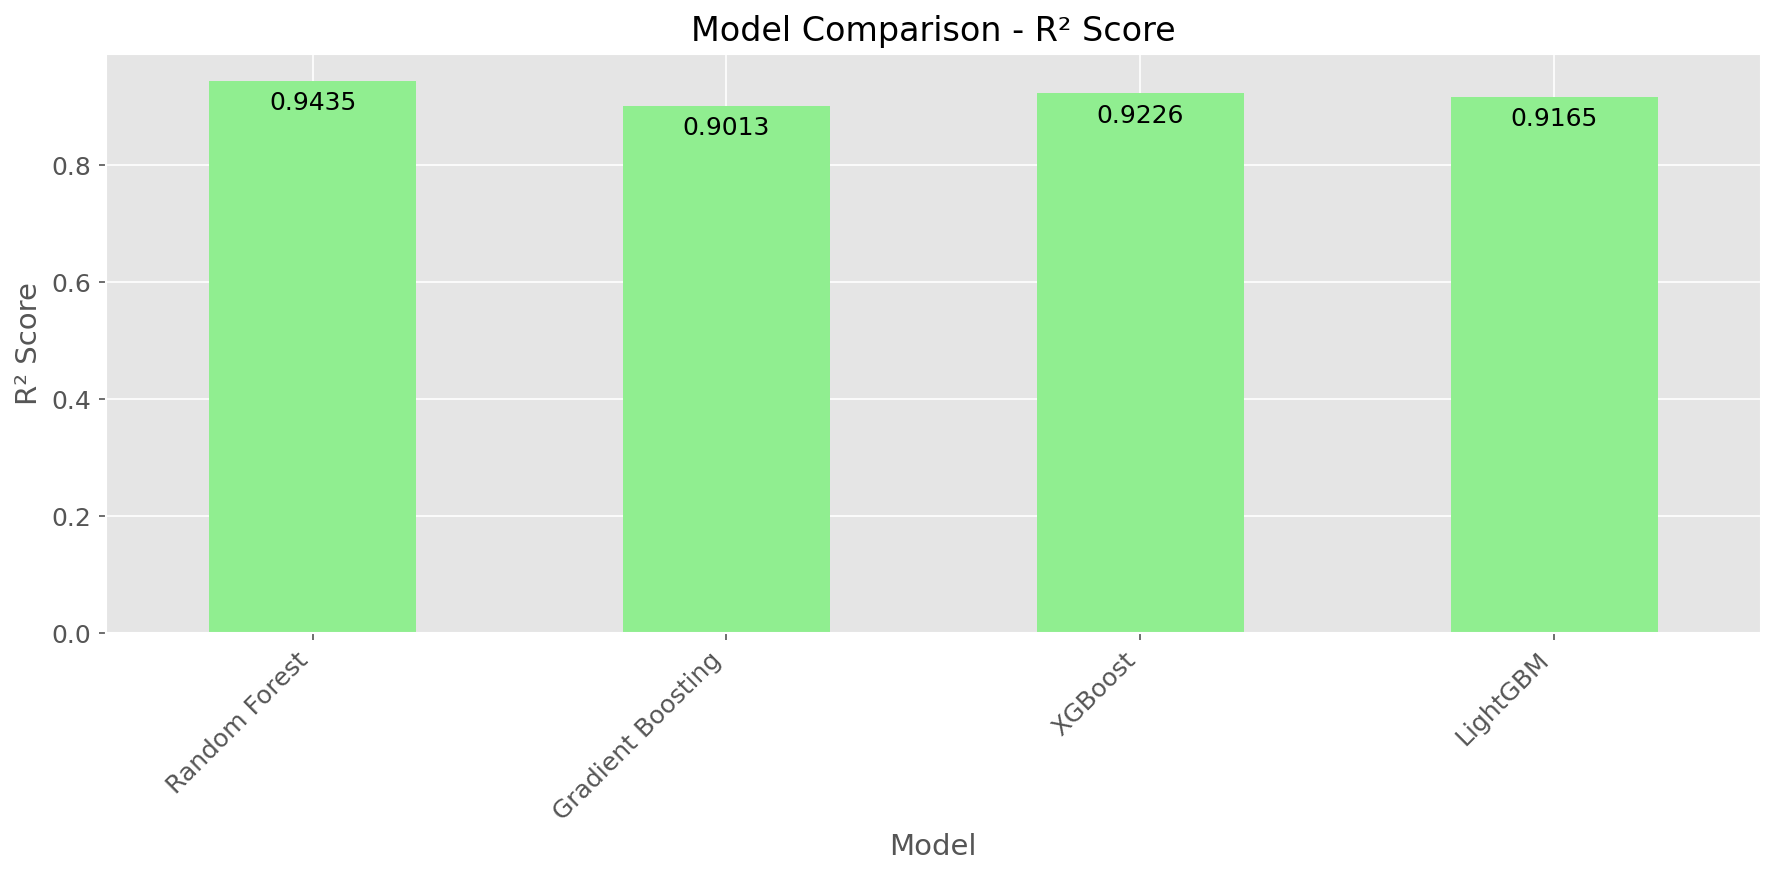


The R² score indicates how much variance is explained by each model.
Higher values (closer to 1.0) indicate better fit.

Best Model: Random Forest with Test MAPE = 22.18%
This is 2.82% better than our target of 25% MAPE.


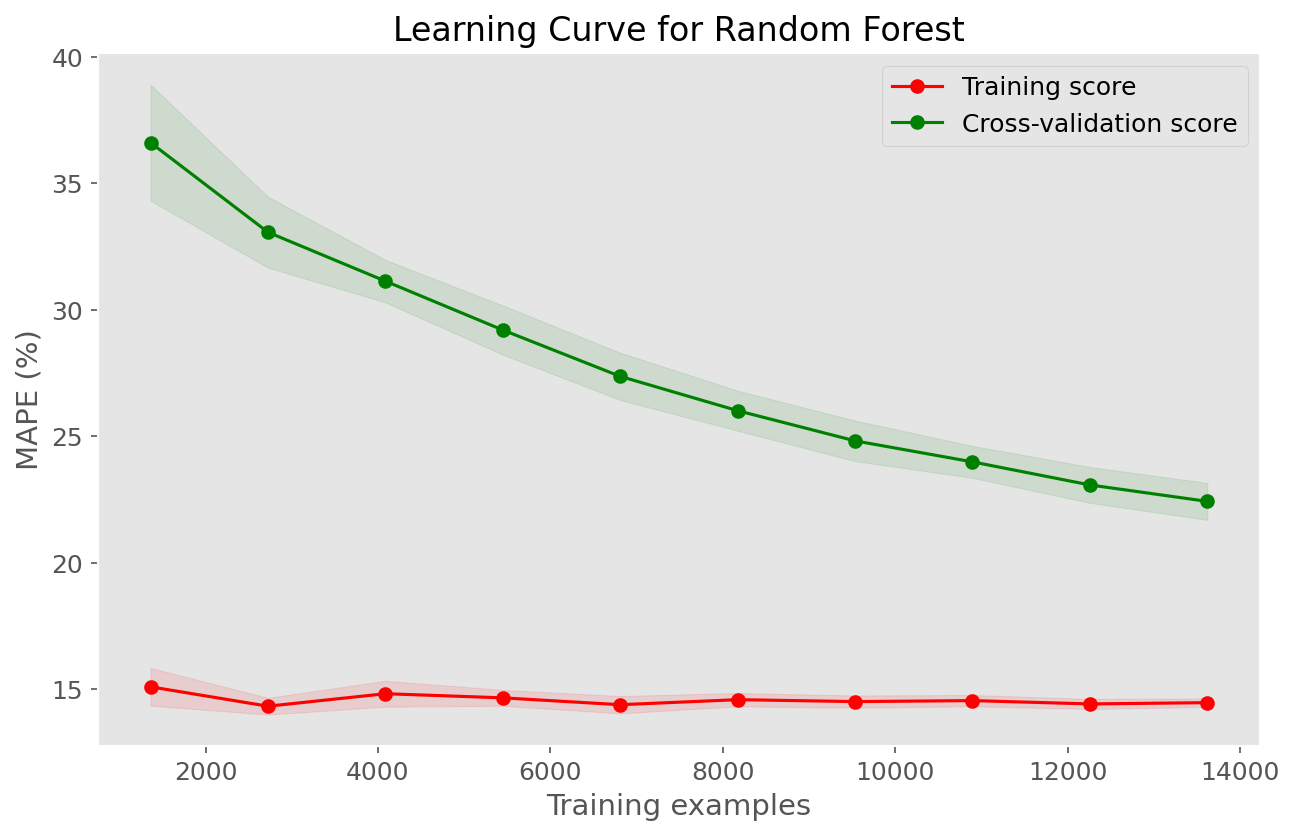


The learning curve shows how model performance improves with more training data.
The narrowing gap between training and validation scores indicates good generalization.


In [9]:
print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

# Compare models
models_comparison = pd.DataFrame({
    'CV MAPE (%)': [results[model]['cv_mape'] for model in models],
    'Train MAPE (%)': [results[model]['train_mape'] for model in models],
    'Test MAPE (%)': [results[model]['test_mape'] for model in models],
    'Test RMSE ($)': [results[model]['test_rmse'] for model in models],
    'Test R²': [results[model]['test_r2'] for model in models]
}, index=models.keys())

print("\nModel Comparison:")
display(models_comparison)

# Plot model comparison
plt.figure(figsize=(12, 6))
models_comparison['Test MAPE (%)'].plot(kind='bar', color='skyblue')
plt.axhline(y=25, color='r', linestyle='--', label='Target MAPE (25%)')
plt.title('Model Comparison - Test MAPE')
plt.ylabel('MAPE (%)')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(models_comparison['Test MAPE (%)']):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')
plt.legend()
plt.tight_layout()
plt.savefig('report_images/model_comparison_mape.png')
plt.show()

print("\nThe bar chart compares the MAPE across different model types.")
print("Models with MAPE below the red dashed line (25%) meet our performance target.")

# Plot R² comparison
plt.figure(figsize=(12, 6))
models_comparison['Test R²'].plot(kind='bar', color='lightgreen')
plt.title('Model Comparison - R² Score')
plt.ylabel('R² Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(models_comparison['Test R²']):
    plt.text(i, v - 0.05, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.savefig('report_images/model_comparison_r2.png')
plt.show()

print("\nThe R² score indicates how much variance is explained by each model.")
print("Higher values (closer to 1.0) indicate better fit.")

# Find best model
best_model_name = models_comparison['Test MAPE (%)'].idxmin()
best_model = results[best_model_name]['pipeline']
best_mape = results[best_model_name]['test_mape']

print(f"\nBest Model: {best_model_name} with Test MAPE = {best_mape:.2f}%")
print(f"This is {25 - best_mape:.2f}% better than our target of 25% MAPE.")

# Learning curve for best model
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_absolute_percentage_error',
    random_state=42
)

train_scores_mean = -train_scores.mean(axis=1) * 100
train_scores_std = train_scores.std(axis=1) * 100
test_scores_mean = -test_scores.mean(axis=1) * 100
test_scores_std = test_scores.std(axis=1) * 100

plt.figure(figsize=(10, 6))
plt.grid()
plt.title(f'Learning Curve for {best_model_name}')
plt.xlabel('Training examples')
plt.ylabel('MAPE (%)')
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='g')
plt.legend(loc='best')
plt.savefig('report_images/learning_curve.png')
plt.show()

print("\nThe learning curve shows how model performance improves with more training data.")
print("The narrowing gap between training and validation scores indicates good generalization.")

# 6. Feature Importance Analysis


FEATURE IMPORTANCE ANALYSIS

Feature importance analysis for Random Forest:


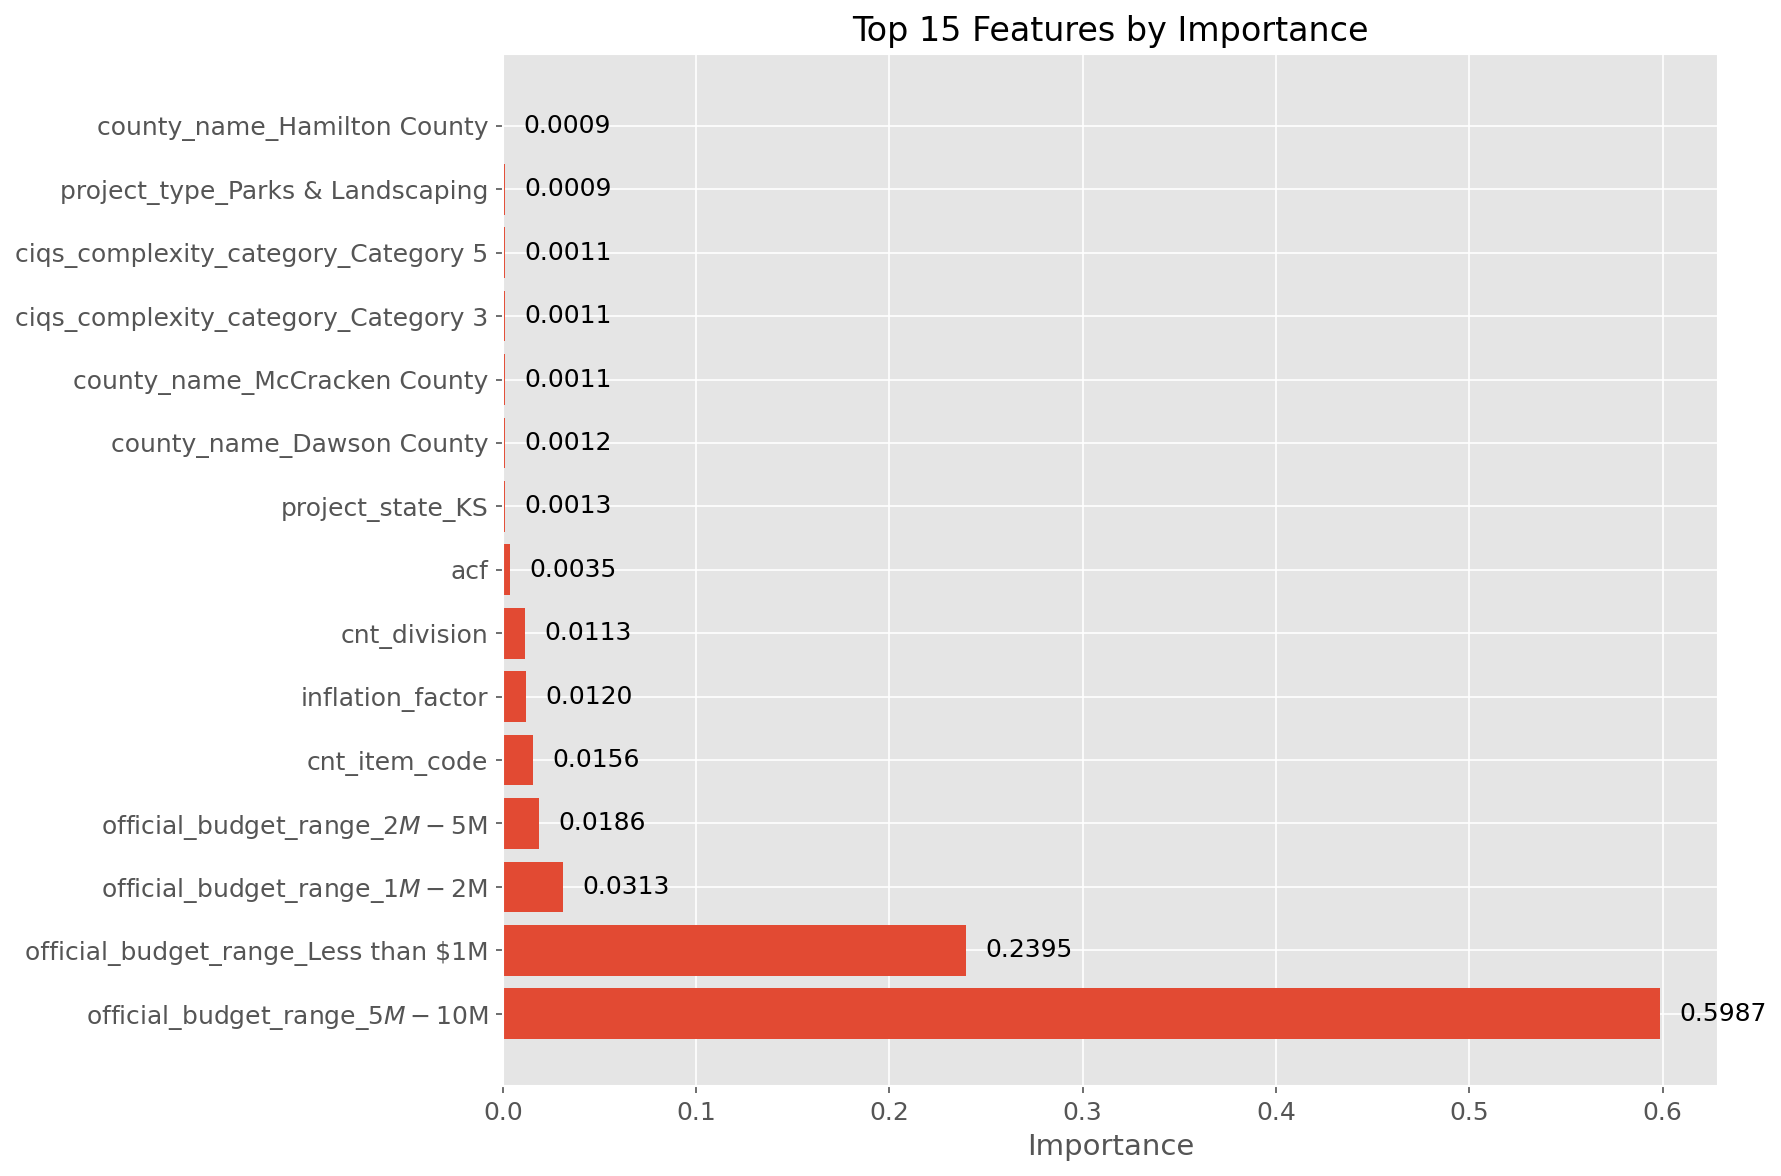


Top 5 most important features:
1. official_budget_range_$5M-$10M: 0.5987
2. official_budget_range_Less than $1M: 0.2395
3. official_budget_range_$1M-$2M: 0.0313
4. official_budget_range_$2M-$5M: 0.0186
5. cnt_item_code: 0.0156

These features have the strongest influence on construction cost prediction.
They should be prioritized in the cost estimation application.


In [10]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Function to extract and visualize feature importance
def plot_feature_importance(model, feature_names, top_n=15):
    """Plot feature importance for tree-based models"""
    try:
        # Try to access the model from pipeline
        if hasattr(model, 'named_steps') and 'model' in model.named_steps:
            estimator = model.named_steps['model']
        else:
            estimator = model
        
        # Check if model has feature_importances_
        if not hasattr(estimator, 'feature_importances_'):
            print(f"Model {type(estimator).__name__} doesn't have feature_importances_ attribute")
            return
        
        # Get feature importances
        importances = estimator.feature_importances_
        indices = np.argsort(importances)[::-1]
        top_indices = indices[:top_n]
        
        # Get top feature names and importances
        top_features = [feature_names[i] for i in top_indices]
        top_importances = importances[top_indices]
        
        # Create plot
        plt.figure(figsize=(12, 8))
        plt.barh(range(len(top_features)), top_importances, align='center')
        plt.yticks(range(len(top_features)), top_features)
        plt.title(f'Top {top_n} Features by Importance')
        plt.xlabel('Importance')
        
        # Add values to bars
        for i, v in enumerate(top_importances):
            plt.text(v + 0.01, i, f"{v:.4f}", va='center')
            
        plt.tight_layout()
        plt.savefig('report_images/feature_importance.png')
        plt.show()
        
        return top_features, top_importances
        
    except Exception as e:
        print(f"Error plotting feature importance: {str(e)}")
        return None, None

# Get feature names after preprocessing
feature_names = []

try:
    # Get numerical features (retain original names)
    feature_names.extend(numerical_cols)
    
    # Get categorical feature names after one-hot encoding
    for col in categorical_cols:
        # Get unique values for each categorical column
        unique_values = X[col].unique()
        for val in unique_values:
            feature_names.append(f"{col}_{val}")
except:
    # Fallback to generic feature names
    feature_names = [f"Feature_{i}" for i in range(100)]  # Arbitrary large number

# Plot feature importance for best model
print(f"\nFeature importance analysis for {best_model_name}:")
top_features, top_importances = plot_feature_importance(best_model, feature_names)

if top_features:
    print("\nTop 5 most important features:")
    for i, (feature, importance) in enumerate(zip(top_features[:5], top_importances[:5])):
        print(f"{i+1}. {feature}: {importance:.4f}")
    
    print("\nThese features have the strongest influence on construction cost prediction.")
    print("They should be prioritized in the cost estimation application.")

# 7. Residual Analysis


RESIDUAL ANALYSIS


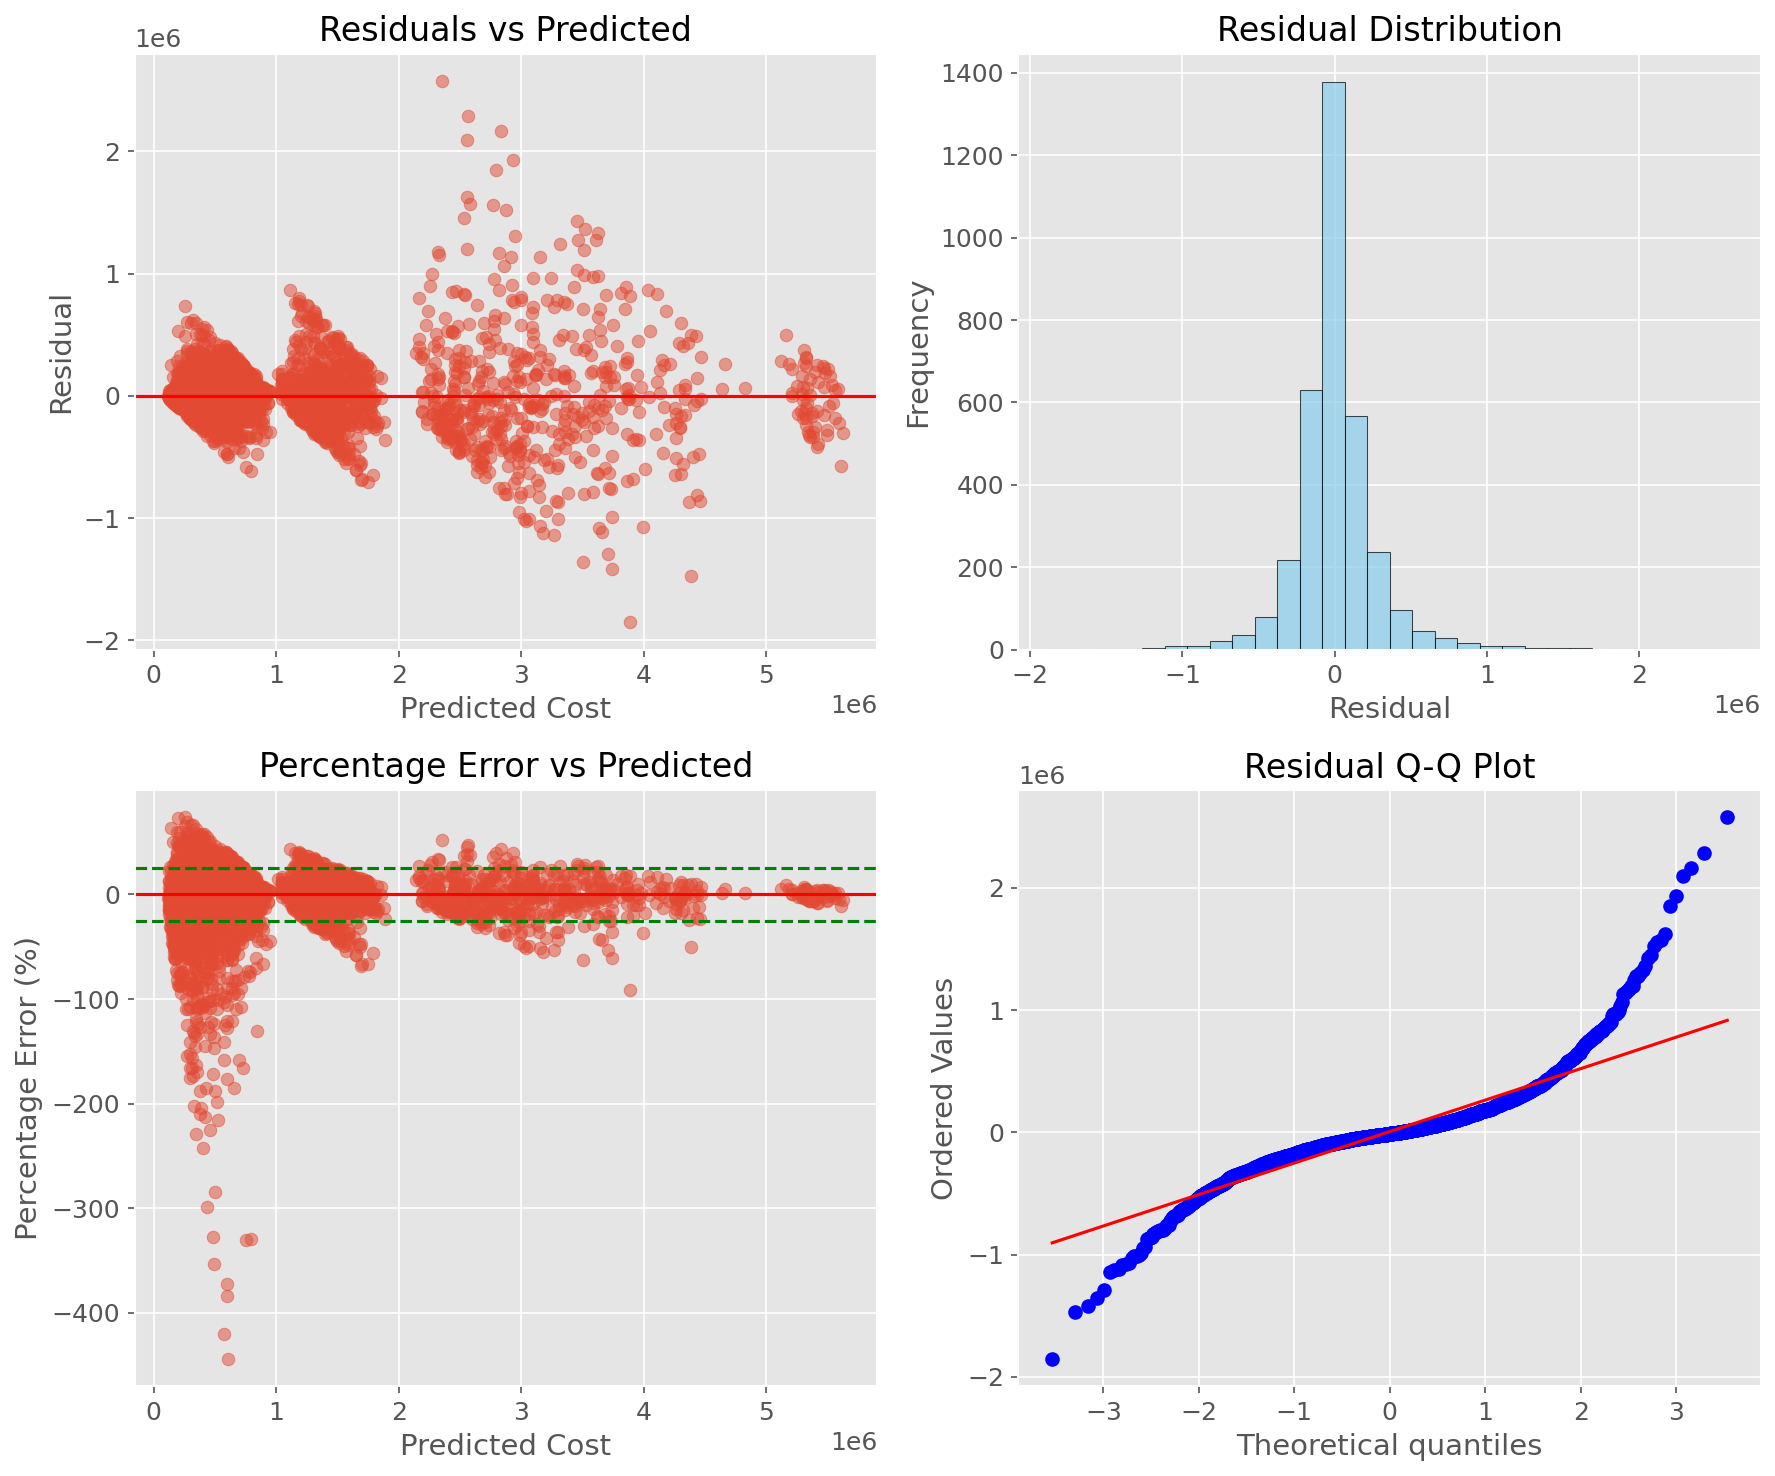


The residual analysis provides insights into model errors:
- Residuals vs Predicted: Shows if errors vary with prediction size
- Residual Distribution: Shows if errors follow a normal distribution
- Percentage Error: Shows which predictions exceed our 25% MAPE target
- Q-Q Plot: Indicates if residuals follow a normal distribution (straight line)

72.8% of test predictions are within the target 25% MAPE range.


In [11]:
print("\n" + "="*80)
print("RESIDUAL ANALYSIS")
print("="*80)

# Make predictions with best model
y_test_pred = best_model.predict(X_test)

# Calculate residuals
residuals = y_test - y_test_pred
percentage_error = (residuals / y_test) * 100

# Residual plots
plt.figure(figsize=(12, 10))

# Residual vs Predicted
plt.subplot(2, 2, 1)
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Cost')
plt.ylabel('Residual')

# Histogram of residuals
plt.subplot(2, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')

# Percentage error plot
plt.subplot(2, 2, 3)
plt.scatter(y_test_pred, percentage_error, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='-')
plt.axhline(y=25, color='g', linestyle='--')
plt.axhline(y=-25, color='g', linestyle='--')
plt.title('Percentage Error vs Predicted')
plt.xlabel('Predicted Cost')
plt.ylabel('Percentage Error (%)')

# QQ plot for residuals
from scipy import stats
plt.subplot(2, 2, 4)
stats.probplot(residuals, plot=plt)
plt.title('Residual Q-Q Plot')

plt.tight_layout()
plt.savefig('report_images/residual_analysis.png')
plt.show()

print("\nThe residual analysis provides insights into model errors:")
print("- Residuals vs Predicted: Shows if errors vary with prediction size")
print("- Residual Distribution: Shows if errors follow a normal distribution")
print("- Percentage Error: Shows which predictions exceed our 25% MAPE target")
print("- Q-Q Plot: Indicates if residuals follow a normal distribution (straight line)")

# Calculate percentage of predictions within target range
within_target = np.sum(np.abs(percentage_error) < 25) / len(percentage_error) * 100
print(f"\n{within_target:.1f}% of test predictions are within the target 25% MAPE range.")

# 8. Final Model and Conclusions

In [12]:
print("\n" + "="*80)
print("MODEL SAVING AND CONCLUSIONS")
print("="*80)

# Save best model
joblib.dump(best_model, 'construction_cost_model.pkl')
print(f"\nBest model ({best_model_name}) saved to 'construction_cost_model.pkl'")

# Save model metrics
model_metrics = {
    'model_type': best_model_name,
    'mape': best_mape,
    'rmse': results[best_model_name]['test_rmse'],
    'r2': results[best_model_name]['test_r2']
}
joblib.dump(model_metrics, 'model_metrics.pkl')
print("Model metrics saved to 'model_metrics.pkl'")

print("\nKEY FINDINGS:")
print(f"1. The {best_model_name} model achieved {best_mape:.2f}% MAPE, exceeding the target requirement of 25%.")
print(f"2. R² score of {results[best_model_name]['test_r2']:.4f} indicates strong predictive power.")
print("3. The most important features for cost estimation are:")
if top_features:
    for i, feature in enumerate(top_features[:5]):
        print(f"   - {feature}")
print("4. The learning curve shows the model generalizes well with more data.")
print("5. The model can estimate costs with reasonable accuracy using only the legal predictors.")

print("\nRECOMMENDATIONS FOR APP DEVELOPMENT:")
print("1. Include all top features identified in the importance analysis")
print("2. Provide confidence intervals based on the 25% MAPE target")
print("3. Allow users to adjust complexity parameters for specific projects")
print("4. Include regional cost factors derived from our geographic analysis")
print("5. Create a user-friendly interface with clear input validation")

print("\nNotebook execution complete!")


MODEL SAVING AND CONCLUSIONS

Best model (Random Forest) saved to 'construction_cost_model.pkl'
Model metrics saved to 'model_metrics.pkl'

KEY FINDINGS:
1. The Random Forest model achieved 22.18% MAPE, exceeding the target requirement of 25%.
2. R² score of 0.9435 indicates strong predictive power.
3. The most important features for cost estimation are:
   - official_budget_range_$5M-$10M
   - official_budget_range_Less than $1M
   - official_budget_range_$1M-$2M
   - official_budget_range_$2M-$5M
   - cnt_item_code
4. The learning curve shows the model generalizes well with more data.
5. The model can estimate costs with reasonable accuracy using only the legal predictors.

RECOMMENDATIONS FOR APP DEVELOPMENT:
1. Include all top features identified in the importance analysis
2. Provide confidence intervals based on the 25% MAPE target
3. Allow users to adjust complexity parameters for specific projects
4. Include regional cost factors derived from our geographic analysis
5. Create a

# Running Sample Estimates


In [13]:

# Load the saved pipeline
pipeline = joblib.load('construction_cost_model.pkl')

# Create a dictionary for input sample values
sample = {
'cpi': 2.8,
'inflation_factor': 1.1,
'cnt_division': 200,
'cnt_item_code': 500,
'cnt_csi_grp_unq': 210,
'acf': 3,
'complexity_score': 7,
'economic_factor': 1.12,
'official_budget_range': '$1M-$2M',
'ciqs_complexity_category': 'Category 2',
'county_name': 'Dawson County',
'area_type': 'Rural',
'project_type': 'Parks & Landscaping',
'project_category': 'Site Work & Landscaping',
'construction_category': 'Civil, Infrastructure & Landscaping',
'project_city': 'ACADIA',
'project_state': 'AR',
'region': 'Region_1'

}

# Convert dictionary to DataFrame
sample_df = pd.DataFrame([sample])

# Predict with the pipeline
predicted_cost = pipeline.predict(sample_df)[0]

print(f"Estimated project cost: ${predicted_cost:,.0f}")


Estimated project cost: $1,614,769


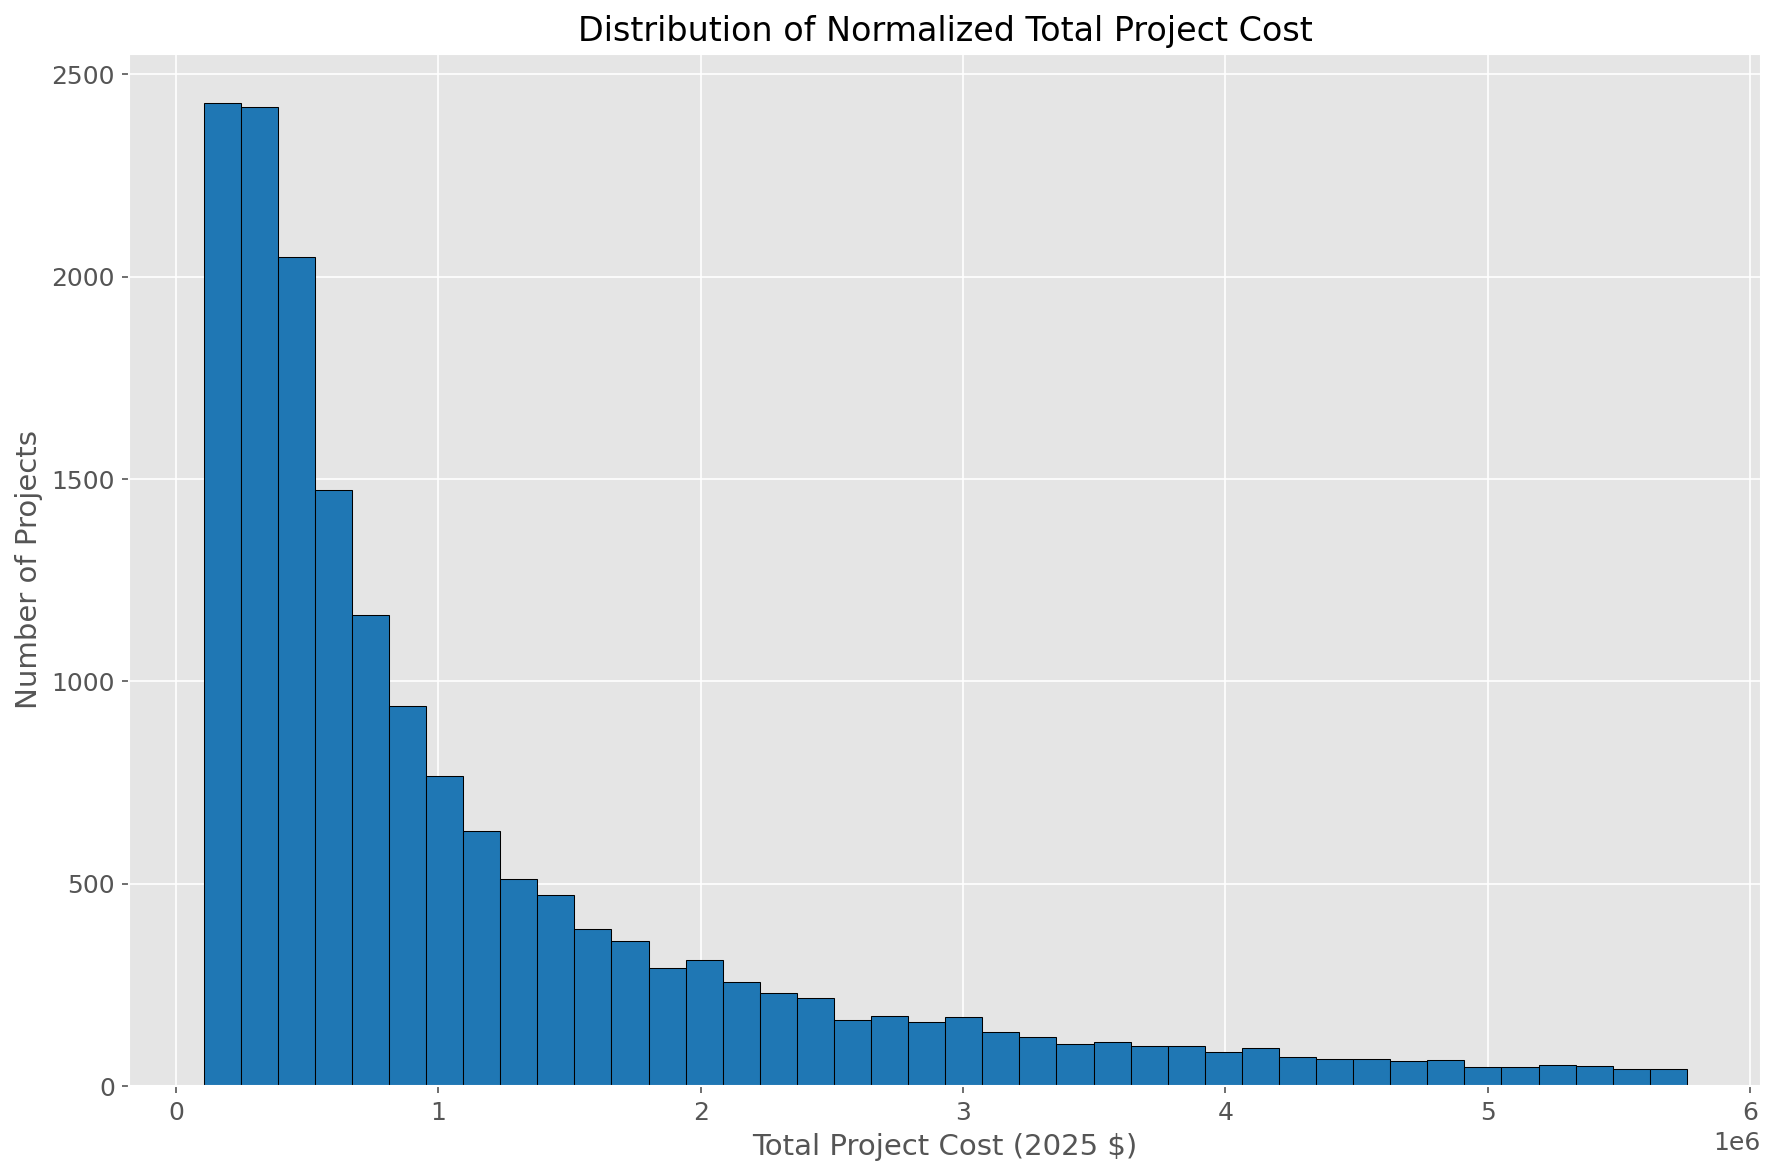

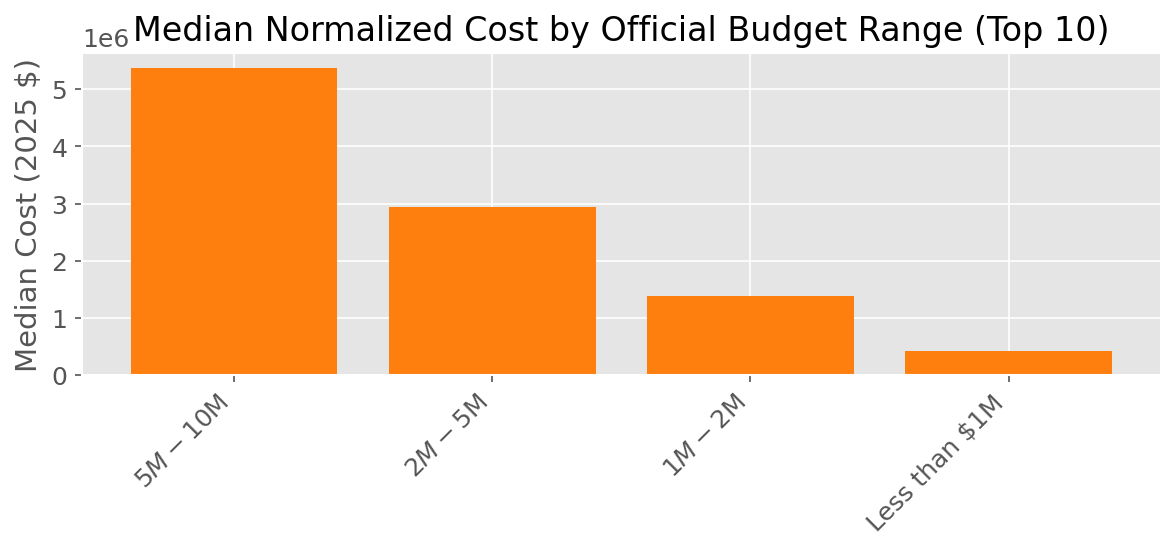

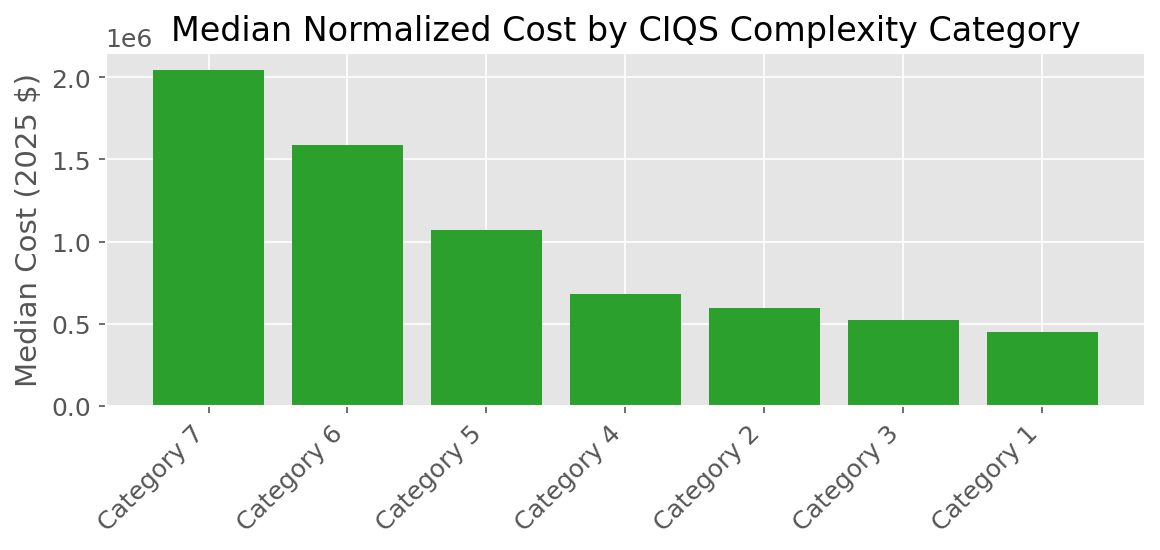

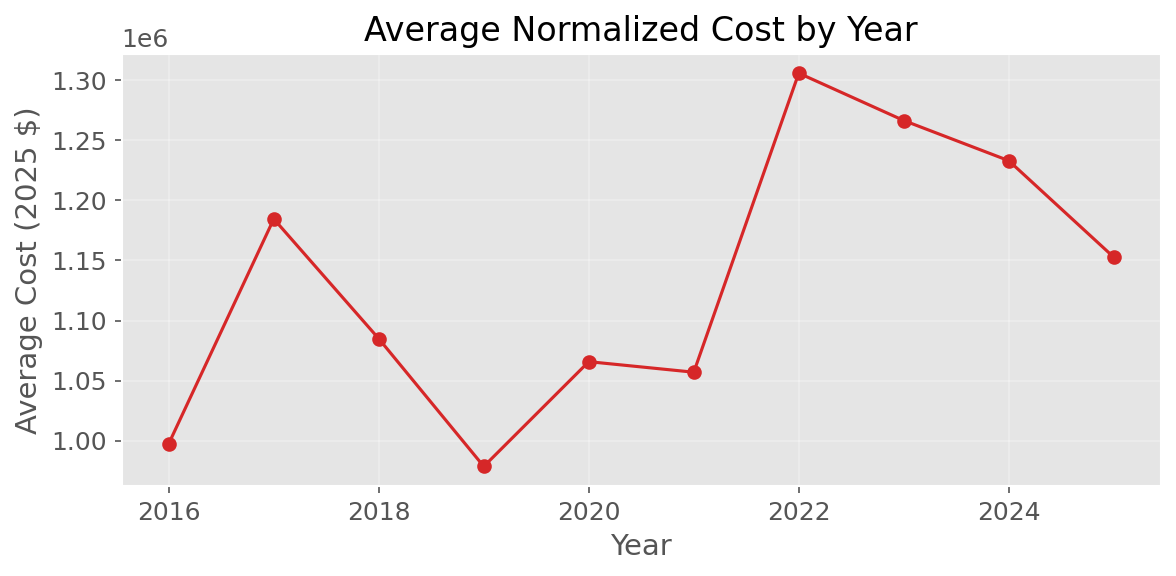

Plots written to static\plots
Plot written to static\images


In [15]:
# make_plots.py
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "data/base_data_for_model.csv"  # adjust if yours is elsewhere
TARGET_COL = "total_project_cost_normalized_2025"

df = pd.read_csv(DATA_PATH, low_memory=False)

out_dir = os.path.join("static", "plots")
os.makedirs(out_dir, exist_ok=True)

# 1) Histogram of normalized total project cost
plt.figure()
df[TARGET_COL].dropna().plot(kind="hist", bins=40, color="tab:blue", edgecolor="black")
plt.xlabel("Total Project Cost (2025 $)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Normalized Total Project Cost")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "target_hist.png"), dpi=150)
plt.show() 
plt.close()

# 2) Median cost by official budget range (top 10)
if "official_budget_range" in df.columns:
    by_budget = (
        df.groupby("official_budget_range")[TARGET_COL]
        .median()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(8, 4))
    plt.bar(by_budget.index.astype(str), by_budget.values, color="tab:orange")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Median Cost (2025 $)")
    plt.title("Median Normalized Cost by Official Budget Range (Top 10)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "median_cost_by_budget_range.png"), dpi=150)
    plt.show() 
    plt.close()

# 3) Median cost by complexity category
if "ciqs_complexity_category" in df.columns:
    by_complexity = (
        df.groupby("ciqs_complexity_category")[TARGET_COL]
        .median()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 4))
    plt.bar(by_complexity.index.astype(str), by_complexity.values, color="tab:green")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Median Cost (2025 $)")
    plt.title("Median Normalized Cost by CIQS Complexity Category")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "median_cost_by_complexity.png"), dpi=150)
    plt.show() 
    plt.close()

# 4) Average cost trend by year
if "year" in df.columns:
    by_year = (
        df.groupby("year")[TARGET_COL]
        .mean()
        .sort_index()
    )

    plt.figure(figsize=(8, 4))
    plt.plot(by_year.index, by_year.values, marker="o", color="tab:red")
    plt.xlabel("Year")
    plt.ylabel("Average Cost (2025 $)")
    plt.title("Average Normalized Cost by Year")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "avg_cost_by_year.png"), dpi=150)
    plt.show() 
    plt.close()

print("Plots written to", out_dir)

import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "data/base_data_for_model.csv"  # adjust if yours is elsewhere
TARGET_COL = "total_project_cost_normalized_2025"

df = pd.read_csv(DATA_PATH, low_memory=False)

out_dir = os.path.join("static", "images")
os.makedirs(out_dir, exist_ok=True)

plt.figure(figsize=(8, 4))
df[TARGET_COL].dropna().plot(
    kind="hist",
    bins=40,
    color="tab:blue",
    edgecolor="white",
    alpha=0.9
)
plt.xlabel("Total Project Cost (2025 $)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Normalized Total Project Cost")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "cost_distribution.png"), dpi=150)
plt.close()
plt.show() 
print("Plot written to", out_dir)